# Final Models: InSeq/OutSeq and Odor Identity Classification (All 5 Rats)

**What this notebook is.** This is the final, presentation-ready notebook for the project. For each
of the two classification tasks it:

1. Runs a dedicated sliding-window search to pick a training window (Section 2), instead of assuming
   one window fits every reference event or every task.
2. Shows what the underlying brain data actually looks like (raw LFP traces, filtered "brainwave"
   bands, and band power), so the audience sees the signal before seeing any classifier output.
3. Trains and rigorously evaluates the final model for **all 5 rats** (repeated cross-validation,
   AUC, permutation test -- same rigor as notebooks 021-023).
4. Shows confusion matrices **one rat at a time** (own figure each), so each one can be dropped
   straight into a slide.
5. Shows a **combined confusion matrix** for each task, built by **summing the raw trial counts**
   across all 5 rats (not averaging percentages), so it reflects the total pool of trials actually
   evaluated.
6. Looks inside the model itself: which frequency band's logistic-regression coefficient ("beta")
   is doing the most work for each task, and in which direction -- the core interpretability question
   for this project.

**Three classification tasks/windows, chosen by search, not by hand:**

| Model | Reference event | Constraint | Min length | Classes |
|---|---|---|---|---|
| InSeq/OutSeq, Poke-In model | Poke-In | offset >= 0 (looks forward from odor onset) AND offset + length <= ~1350ms (never runs past Poke-Out) | 1000 ms | 2 (OutSeq / InSeq) |
| InSeq/OutSeq, Poke-Out model | Poke-Out | offset + length <= 100ms (ends at, or only slightly after, withdrawal) | 1000 ms | 2 (OutSeq / InSeq) |
| Odor Identity | Poke-In | offset + length <= ~1350ms (stays within the Poke-In -> Poke-Out gap) | 1000 ms | 5 (A/B/C/D/E), InSeq trials only |

**Why two separate InSeq/OutSeq models instead of one.** InSeq/OutSeq is a question about the rat's
behavior around withdrawal, so a window that looks *forward from Poke-In* and a window that looks
*backward from Poke-Out* are answering genuinely different questions ("can the decision be seen
building up" vs. "can the decision be seen right up until the moment it's made") and are allowed to land
on different lengths and different offsets. They are searched completely independently below, on
purpose -- one is never assumed to also work for the other. The Poke-Out model is the one used for
interpretability later in the notebook, since it is the strictest test of a genuinely pre-decision
signal; the Poke-In model's numbers are reported in full in Section 2a for comparison.

**Overfitting safeguard.** Every window search below screens candidates with a repeated (not
single-split) cross-validation, and Section 2e re-runs the full screen-and-select procedure several
more times with different CV shuffles to check that the winning window isn't just an artifact of one
lucky fold split, before anything gets reported as final.

**Assumed project layout** (same as every other notebook in this project): this notebook lives in the
`notebooks/` folder, with `../data/raw/<session>/` holding the four `.npz` files per rat and
`../src/preprocessing.py` providing `build_labels` and `get_sampling_rate`.


## 1. Setup

In [1]:
import sys
sys.path.append('..')

import os
import json as _json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

from src.preprocessing import build_labels, get_sampling_rate

RAW_DIR = Path('../data/raw')
SESSION_DIRS = sorted([p for p in RAW_DIR.iterdir() if p.is_dir()])
RAT_LABELS = {s.name: s.name.split('_')[1].capitalize() for s in SESSION_DIRS}

FIG_DIR = Path('../outputs/figures')
LOG_DIR = Path('../outputs/logs')
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}

N_PERMUTATIONS = 99  # permutation-test null-distribution draws, used by run_full_evaluation
INSEQ_CLASS_NAMES = ['OutSeq', 'InSeq']  # shared class labels for every InSeq/OutSeq confusion matrix

# Constraints applied to every window search in Section 2: a window must be at least this long, and
# the Poke-In-anchored search, the Poke-Out-anchored search, and the Odor Identity search are each run
# completely independently -- none of them is allowed to just reuse another one's winning window.
MIN_WINDOW_LENGTH_MS = 1000

# Screening now averages this many 5-fold CV repeats per candidate window (instead of a single 5-fold
# split) before ranking candidates, so the window that "wins" a search is less likely to just be a
# lucky fold split. See Section 2e for a further check on top of this.
SCREEN_CV_REPEATS = 3

# INSEQ_WINDOW and ODOR_WINDOW are set for real in Section 2, once each search below has picked its
# winner (INSEQ_WINDOW ends up pointing at the Poke-Out model, the stricter of the two InSeq/OutSeq
# windows; ODOR_WINDOW points at the new Odor Identity search winner). Every cell in Sections 3 and 4
# (EDA / raw-data plots) and Section 6 (interpretability) reads these two names, so once Section 2 has
# run, those cells automatically reflect whatever the searches picked -- nothing else needs editing.

print(f"Found {len(SESSION_DIRS)} sessions: {[s.name for s in SESSION_DIRS]}")
print(f"Minimum window length enforced in every search below: {MIN_WINDOW_LENGTH_MS}ms")


Found 5 sessions: ['080718_mitt', '081106_barat', '090212_stella', '090212_superchris', '090420_buchanan']
Minimum window length enforced in every search below: 1000ms


### Helper functions

Same window-extraction / feature-building logic used in notebooks 020-023, collected here in one
place since this notebook uses it for both the EDA visualizations and the final models.

In [2]:
def find_pokeout_idx(bvr_data, bvr_keys, timebin, trial_idx):
    """For each trial's Poke-In sample, find the first PokeEvents entry strictly between it and the
    NEXT trial's Poke-In (the notebook-020 fix that prevents leaking into the next trial)."""
    poke_events_row = bvr_data[bvr_keys.index('PokeEvents')]
    poke_event_idx = np.where(poke_events_row != 0)[0]
    pokeout_idx = np.full(len(trial_idx), -1, dtype=np.int64)
    for i, t in enumerate(trial_idx):
        next_bound = trial_idx[i + 1] if i + 1 < len(trial_idx) else len(timebin)
        candidates = poke_event_idx[(poke_event_idx > t) & (poke_event_idx < next_bound)]
        if len(candidates) > 0:
            pokeout_idx[i] = candidates[0]
    return pokeout_idx


def extract_window(lfp_data, timebin, ref_idx, offset_ms, length_ms, target_samples):
    """Cut [ref_time + offset_ms, + length_ms] out of the LFP, resampled to a fixed sample count so
    every trial's feature vector has the same length regardless of tiny sampling-rate jitter."""
    if ref_idx < 0:
        return None
    ref_time = timebin[ref_idx]
    start_time = ref_time + offset_ms / 1000
    end_time = start_time + length_ms / 1000
    if start_time < timebin[0] or end_time > timebin[-1]:
        return None
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None
    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features(windows, fs, bands):
    """FFT-based power-per-band, per channel. Returns (n_trials, n_channels * n_bands)."""
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            col += 1
    return X


def load_session(session_dir):
    """Load bvr + lfp for one session, plus derived timebin/fs/labels/pokeout, all in one dict."""
    session_name = session_dir.name
    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']
    lfp_keys = lfp['keys'].tolist()  # real electrode/tetrode names, e.g. 'T1_LFP_Raw' -- used for plot labels
    timebin = bvr_data[bvr_keys.index('TimeBin')]
    fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)
    pokeout_idx = find_pokeout_idx(bvr_data, bvr_keys, timebin, labels['trial_idx'])
    return {
        'name': session_name, 'bvr_data': bvr_data, 'bvr_keys': bvr_keys,
        'lfp_data': lfp_data, 'lfp_keys': lfp_keys, 'timebin': timebin, 'fs': fs, 'labels': labels,
        'pokeout_idx': pokeout_idx,
    }


def get_features_for_window(sess, window_cfg, task):
    """task = 'inseq' (all trials, 2-class) or 'odor' (InSeq trials only, 5-class)."""
    timebin, fs, labels = sess['timebin'], sess['fs'], sess['labels']
    target_samples = int(round(window_cfg['length_ms'] / 1000 * fs))
    if window_cfg['reference'] == 'pokein':
        ref_indices = labels['trial_idx']
    else:
        ref_indices = sess['pokeout_idx']

    windows, kept_positions = [], []
    for i, ref_idx in enumerate(ref_indices):
        w = extract_window(sess['lfp_data'], timebin, ref_idx, window_cfg['offset_ms'], window_cfg['length_ms'], target_samples)
        if w is not None:
            windows.append(w)
            kept_positions.append(i)
    windows = np.stack(windows, axis=0)
    kept_positions = np.array(kept_positions)

    if task == 'inseq':
        y = labels['inseq_outseq'][kept_positions]
        X = np.log1p(band_power_features(windows, fs, BANDS))
        return X, y
    elif task == 'odor':
        inseq_mask = labels['inseq_outseq'][kept_positions] == 1
        y = labels['odor_id'][kept_positions][inseq_mask]
        X = np.log1p(band_power_features(windows[inseq_mask], fs, BANDS))
        return X, y
    else:
        raise ValueError(task)


def make_pipeline():
    return Pipeline([('scaler', StandardScaler()),
                      ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])


def run_full_evaluation(X, y, class_labels, auc_scoring='roc_auc'):
    """Repeated CV balanced accuracy + AUC, a single-split confusion matrix, and a permutation test.
    Same rigor used in notebooks 021-023."""
    pipe = make_pipeline()
    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    bal_acc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='balanced_accuracy')
    auc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring=auc_scoring)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    preds = cross_val_predict(pipe, X, y, cv=skf)
    cm = confusion_matrix(y, preds, labels=class_labels)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    rng = np.random.RandomState(42)
    null_scores = []
    for i in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y)
        skf_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
        null_scores.append(cross_val_score(pipe, X, y_shuffled, cv=skf_i, scoring='balanced_accuracy').mean())
    null_scores = np.array(null_scores)
    p_value = (np.sum(null_scores >= bal_acc_scores.mean()) + 1) / (N_PERMUTATIONS + 1)

    return {
        'balanced_accuracy': float(bal_acc_scores.mean()),
        'auc': float(auc_scores.mean()),
        'cm_counts': cm,
        'cm_pct': cm_pct,
        'p_value': float(p_value),
    }


def plot_confusion_matrix(cm_pct, class_names, title, ax=None, annotate_extra=None):
    """One rat's confusion matrix, as its own small figure (easy to screenshot for a slide)."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.2, 4.2))
    n = len(class_names)
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(n)); ax.set_xticklabels(class_names)
    ax.set_yticks(range(n)); ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=11)
    for i in range(n):
        for j in range(n):
            label = f'{cm_pct[i, j]:.0f}%'
            if annotate_extra is not None:
                label += f'\n(n={int(annotate_extra[i, j])})'
            ax.text(j, i, label, ha='center', va='center', fontsize=9,
                    color='white' if cm_pct[i, j] > 50 else 'black')
    if own_fig:
        plt.tight_layout()
        return fig
    return None


In [3]:
sessions = {sd.name: load_session(sd) for sd in SESSION_DIRS}
print("Loaded:", list(sessions.keys()))


Loaded: ['080718_mitt', '081106_barat', '090212_stella', '090212_superchris', '090420_buchanan']


## 2. Window Selection

Before looking at any brain data or training a final model, this section picks the training window
for each of the three models above. The rule for all three searches is the same: **decide the
candidate grid from the behavioral logic first** (which direction in time makes sense to look, and how
long the window has to be), then let cross-validated accuracy pick the winner from inside that grid --
never the other way around.


### 2a. Final Model, InSeq/OutSeq -- Poke-In Window

Looks only at brain activity **after** Poke-In (`offset_ms >= 0`), since that is the only direction
that makes sense for a window anchored to odor onset -- this asks how well InSeq/OutSeq can be decoded
using only brain activity building up after the odor turns on, without needing to already know Poke-Out
has happened. It is also capped so it can never run past Poke-Out at all (`offset_ms + length_ms <=
TYPICAL_POKEIN_POKEOUT_GAP_MS`, the population-average Poke-In -> Poke-Out gap) -- a window that
overran Poke-Out would no longer be answering "can the decision be seen building up before it's made",
it would just be leaking post-decision activity back in through the Poke-In side.

**Search grid:** offsets from 0ms in 50ms steps up to that ceiling, x lengths 1000-1500ms in 100ms
steps (every candidate satisfies the notebook-wide `MIN_WINDOW_LENGTH_MS = 1000` floor), keeping only
combinations where `offset_ms + length_ms <= TYPICAL_POKEIN_POKEOUT_GAP_MS`.

**Screening:** `SCREEN_CV_REPEATS` repeats of 5-fold CV per candidate, averaged, instead of a single
5-fold split -- the averaging is what Section 2e's stability check is layered on top of.

**Selection rule:** maximize the *worst* balanced accuracy across all 5 rats (maximin), the same
rule used throughout this project since notebook 022, so a window can't win just by overfitting to
whichever rat happens to be easiest.


In [4]:
# Population-average Poke-In -> Poke-Out gap, used as a hard ceiling so this Poke-In-anchored window
# can never run into (or past) Poke-Out -- see markdown above. Also reused by the Odor Identity search
# in Section 2d below, so both Poke-In-anchored searches respect exactly the same ceiling.
TYPICAL_POKEIN_POKEOUT_GAP_MS = 1350  # ~1.3-1.4s, population average, see EDA in Section 3/4

POKEIN_OFFSETS_MS = list(range(0, TYPICAL_POKEIN_POKEOUT_GAP_MS - MIN_WINDOW_LENGTH_MS + 1, 50))
POKEIN_LENGTHS_MS = [1000, 1100, 1200, 1300, 1400, 1500]  # every length satisfies MIN_WINDOW_LENGTH_MS
POKEIN_CANDIDATES = [
    {'name': f'pokein_{off}_{length}', 'reference': 'pokein', 'offset_ms': off, 'length_ms': length}
    for off in POKEIN_OFFSETS_MS for length in POKEIN_LENGTHS_MS
    if off + length <= TYPICAL_POKEIN_POKEOUT_GAP_MS
]
print(f"{len(POKEIN_CANDIDATES)} candidates: offsets {POKEIN_OFFSETS_MS[0]}-{POKEIN_OFFSETS_MS[-1]}ms "
      f"(step 50ms) x lengths {POKEIN_LENGTHS_MS}, every one satisfying "
      f"offset_ms + length_ms <= {TYPICAL_POKEIN_POKEOUT_GAP_MS}ms (never runs past Poke-Out)")


20 candidates: offsets 0-350ms (step 50ms) x lengths [1000, 1100, 1200, 1300, 1400, 1500], every one satisfying offset_ms + length_ms <= 1350ms (never runs past Poke-Out)


#### Screening pass (repeated CV per candidate, all rats)

In [5]:
pokein_screening = {}  # pokein_screening[cfg_name][rat_name] = mean balanced_accuracy over SCREEN_CV_REPEATS folds

for sd in SESSION_DIRS:
    name = sd.name
    sess = sessions[name]
    for cfg in POKEIN_CANDIDATES:
        X, y = get_features_for_window(sess, cfg, task='inseq')
        if len(y) < 20 or len(np.unique(y)) < 2:
            score = np.nan
        else:
            pipe = make_pipeline()
            rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=SCREEN_CV_REPEATS, random_state=42)
            score = cross_val_score(pipe, X, y, cv=rskf, scoring='balanced_accuracy').mean()
        pokein_screening.setdefault(cfg['name'], {})[name] = score
    print(f"{RAT_LABELS[name]} screened ({len(POKEIN_CANDIDATES)}/{len(POKEIN_CANDIDATES)} candidates)")

print("\nScreening complete.")

Mitt screened (20/20 candidates)
Barat screened (20/20 candidates)
Stella screened (20/20 candidates)
Superchris screened (20/20 candidates)
Buchanan screened (20/20 candidates)

Screening complete.


#### Where is the InSeq/OutSeq signal strongest, strictly after Poke-In?

Each panel is one rat: x-axis = how long after Poke-In the window starts, y-axis = how long the window
runs (1000/1250/1500ms only), color = mean balanced accuracy across the repeated CV screen. The red
star marks that rat's individual best -- not necessarily the overall winner, since the winner is chosen
by the maximin rule below (worst balanced accuracy across all 5 rats), not per-rat.


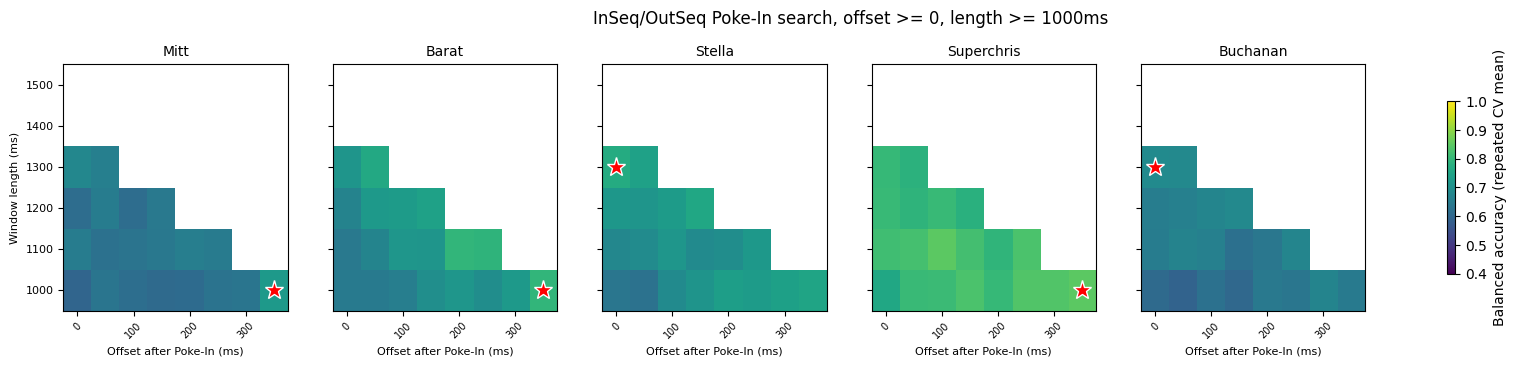

In [6]:
fig, axes = plt.subplots(1, len(SESSION_DIRS), figsize=(4.2 * len(SESSION_DIRS), 3.2), sharey=True)
for ax, sd in zip(np.atleast_1d(axes), SESSION_DIRS):
    name = sd.name
    grid = np.full((len(POKEIN_LENGTHS_MS), len(POKEIN_OFFSETS_MS)), np.nan)
    for i, length in enumerate(POKEIN_LENGTHS_MS):
        for j, offset in enumerate(POKEIN_OFFSETS_MS):
            # Not every (offset, length) cell in this rectangular grid is a real candidate -- any
            # combo with offset + length > TYPICAL_POKEIN_POKEOUT_GAP_MS was filtered out back in the
            # candidate list (it would have run past Poke-Out), so it was never screened. Leave those
            # cells as NaN (already the grid's fill value) instead of a KeyError.
            key = f'pokein_{offset}_{length}'
            if key in pokein_screening:
                grid[i, j] = pokein_screening[key][name]
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='viridis', vmin=0.4, vmax=1.0)
    ax.set_xticks(range(0, len(POKEIN_OFFSETS_MS), 2)); ax.set_xticklabels(POKEIN_OFFSETS_MS[::2], rotation=45, fontsize=7)
    ax.set_yticks(range(len(POKEIN_LENGTHS_MS))); ax.set_yticklabels(POKEIN_LENGTHS_MS, fontsize=8)
    ax.set_xlabel('Offset after Poke-In (ms)', fontsize=8)
    ax.set_title(RAT_LABELS[name], fontsize=10)
    bi, bj = np.unravel_index(np.nanargmax(grid), grid.shape)
    ax.plot(bj, bi, marker='*', color='red', markersize=14, markeredgecolor='white')
axes[0].set_ylabel('Window length (ms)', fontsize=8)
fig.colorbar(im, ax=axes.tolist(), shrink=0.7, label='Balanced accuracy (repeated CV mean)')
plt.suptitle(f'InSeq/OutSeq Poke-In search, offset >= 0, length >= {MIN_WINDOW_LENGTH_MS}ms', y=1.05)
plt.savefig(FIG_DIR / 'pokein_inseq_sliding_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### Selecting the winner (maximin rule across all 5 rats)

In [7]:
best_name, best_score = None, -1
for name, scores in pokein_screening.items():
    values = list(scores.values())
    if np.any(np.isnan(values)):
        continue
    key_score = min(values)
    if key_score > best_score:
        best_score, best_name = key_score, name

winning_pokein_config = next(c for c in POKEIN_CANDIDATES if c['name'] == best_name)
print(f"Winner: {best_name} -> {winning_pokein_config}")


Winner: pokein_0_1300 -> {'name': 'pokein_0_1300', 'reference': 'pokein', 'offset_ms': 0, 'length_ms': 1300}


#### Full rigorous evaluation of the winning Poke-In window

Same repeated CV + AUC + permutation-test rigor as every other final model in this notebook.


In [8]:
pokein_inseq_results = {}
for sd in SESSION_DIRS:
    name = sd.name
    print(f"Evaluating {RAT_LABELS[name]}...")
    X, y = get_features_for_window(sessions[name], winning_pokein_config, task='inseq')
    result = run_full_evaluation(X, y, class_labels=[0, 1], auc_scoring='roc_auc')
    pokein_inseq_results[name] = result
    print(f"  balanced_accuracy={result['balanced_accuracy']:.3f}  AUC={result['auc']:.3f}  p={result['p_value']:.4f}")


Evaluating Mitt...
  balanced_accuracy=0.679  AUC=0.737  p=0.0100
Evaluating Barat...
  balanced_accuracy=0.726  AUC=0.826  p=0.0100
Evaluating Stella...
  balanced_accuracy=0.769  AUC=0.867  p=0.0100
Evaluating Superchris...
  balanced_accuracy=0.788  AUC=0.862  p=0.0100
Evaluating Buchanan...
  balanced_accuracy=0.691  AUC=0.779  p=0.0100


#### Confusion matrices, Poke-In InSeq/OutSeq model, one rat per figure

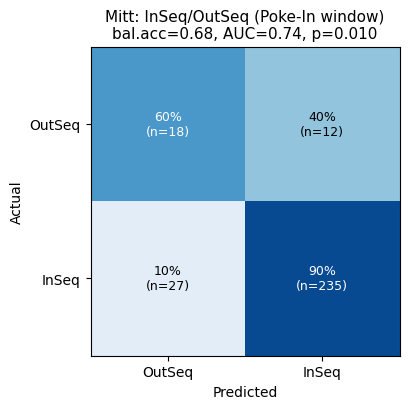

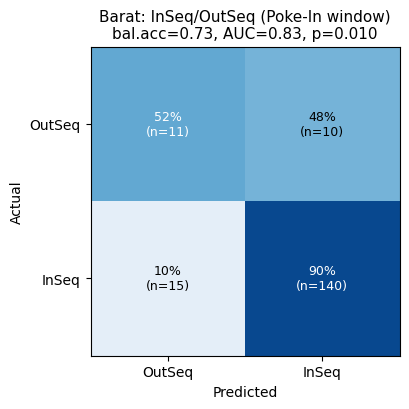

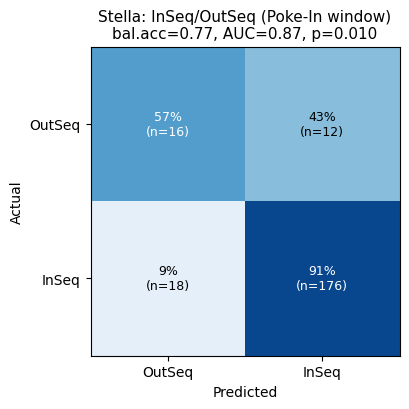

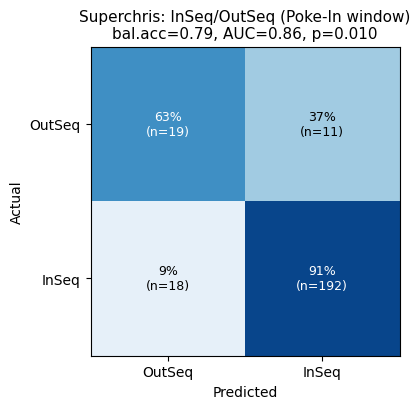

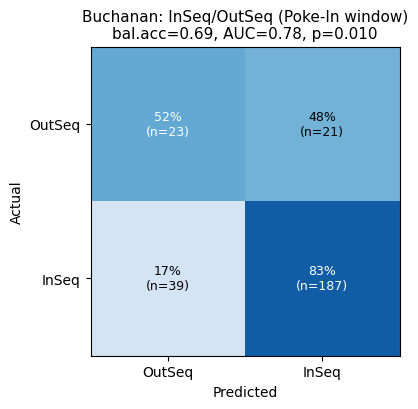

In [9]:
for name, r in pokein_inseq_results.items():
    fig = plot_confusion_matrix(
        r['cm_pct'], INSEQ_CLASS_NAMES,
        title=f"{RAT_LABELS[name]}: InSeq/OutSeq (Poke-In window)\nbal.acc={r['balanced_accuracy']:.2f}, AUC={r['auc']:.2f}, p={r['p_value']:.3f}",
        annotate_extra=r['cm_counts'],
    )
    fig.savefig(FIG_DIR / f'confusion_inseq_pokein_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


#### Combined confusion matrix -- all 5 rats, totals summed

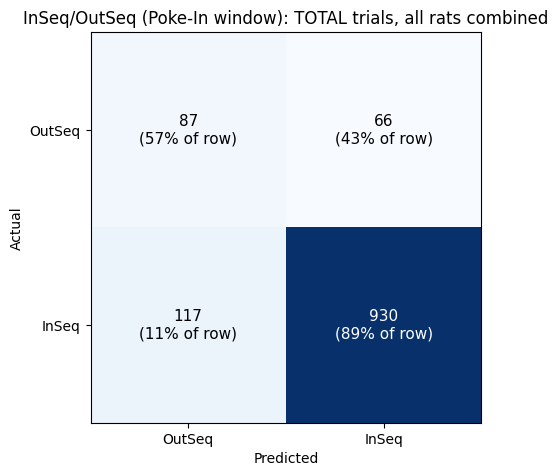

Total trials evaluated across available rats: 1200
Total trials evaluated across available rats: 1200
Combined AUC (trial-weighted average across rats) 0.808


In [10]:
combined_pokein_inseq_counts = np.zeros((2, 2))
for r in pokein_inseq_results.values():
    combined_pokein_inseq_counts += r['cm_counts']
combined_pokein_inseq_pct = combined_pokein_inseq_counts / combined_pokein_inseq_counts.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(combined_pokein_inseq_counts, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(INSEQ_CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(INSEQ_CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('InSeq/OutSeq (Poke-In window): TOTAL trials, all rats combined')
vmax = combined_pokein_inseq_counts.max()
for i in range(2):
    for j in range(2):
        val = combined_pokein_inseq_counts[i, j]
        ax.text(j, i, f'{int(val)}\n({combined_pokein_inseq_pct[i, j]:.0f}% of row)', ha='center', va='center',
                fontsize=11, color='white' if val > vmax / 2 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_inseq_pokein_combined_total.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total trials evaluated across available rats: {int(combined_pokein_inseq_counts.sum())}")

combined_pokein_inseq_auc = sum(r['auc'] * r['cm_counts'].sum() for r in pokein_inseq_results.values()) / combined_pokein_inseq_counts.sum()
print(f"Total trials evaluated across available rats: {int(combined_pokein_inseq_counts.sum())}")
print(f"Combined AUC (trial-weighted average across rats) {combined_pokein_inseq_auc:.3f}")


### 2b. Final Model, InSeq/OutSeq -- Poke-Out Window

Looks only at brain activity **before, or only slightly after, Poke-Out**
(`offset_ms + length_ms <= POKEOUT_MAX_LOOKAHEAD_MS`), so whatever accuracy this model gets is mostly
explained by activity that preceded the rat's withdrawal, with only a small amount of allowed
lookahead rather than none at all. This is deliberately a completely separate search from 2a above,
not a copy of it with the sign flipped -- it has its own offset grid, and there is no requirement
that it land on the same length as the Poke-In model.

**Search grid:** rather than assuming one particular length or end-point is correct, this searches both
how long the window should be *and* where it ends relative to Poke-Out -- end-points from -750ms up to
`POKEOUT_MAX_LOOKAHEAD_MS` in 50ms steps, x lengths 1000-1500ms in 100ms steps (the same
`MIN_WINDOW_LENGTH_MS` floor as 2a), every one satisfying `offset_ms + length_ms <=
POKEOUT_MAX_LOOKAHEAD_MS`.

**Screening and selection rule:** identical methodology to 2a -- `SCREEN_CV_REPEATS`-repeated 5-fold CV
per candidate, maximin winner across all 5 rats.


In [11]:
# A small amount of lookahead past Poke-Out is allowed (deliberately little), rather than forcing
# every candidate to end exactly at or before Poke-Out -- see markdown above.
POKEOUT_MAX_LOOKAHEAD_MS = 100

PREPOKEOUT_END_OFFSETS_MS = list(range(-750, POKEOUT_MAX_LOOKAHEAD_MS + 1, 50))   # how far the window ENDS relative to Poke-Out (0 = ends exactly at Poke-Out, positive = a little after)
PREPOKEOUT_LENGTHS_MS = [1000, 1100, 1200, 1300, 1400, 1500]  # every length satisfies MIN_WINDOW_LENGTH_MS

PREPOKEOUT_CANDIDATES = [
    {'name': f'prepokeout_end{end}_len{length}', 'reference': 'pokeout',
     'offset_ms': end - length, 'length_ms': length}
    for end in PREPOKEOUT_END_OFFSETS_MS for length in PREPOKEOUT_LENGTHS_MS
]
print(f"{len(PREPOKEOUT_CANDIDATES)} candidates: every one satisfies offset_ms + length_ms <= "
      f"{POKEOUT_MAX_LOOKAHEAD_MS}ms (ends at or only slightly after Poke-Out) -- end points "
      f"{PREPOKEOUT_END_OFFSETS_MS[0]} to {PREPOKEOUT_END_OFFSETS_MS[-1]}ms, lengths {PREPOKEOUT_LENGTHS_MS}")


108 candidates: every one satisfies offset_ms + length_ms <= 100ms (ends at or only slightly after Poke-Out) -- end points -750 to 100ms, lengths [1000, 1100, 1200, 1300, 1400, 1500]


#### Screening all candidates, all 5 rats

In [12]:
prepokeout_screening = {}  # prepokeout_screening[cfg_name][rat_name] = mean balanced_accuracy over SCREEN_CV_REPEATS folds

for sd in SESSION_DIRS:
    name = sd.name
    sess = sessions[name]
    for cfg in PREPOKEOUT_CANDIDATES:
        X, y = get_features_for_window(sess, cfg, task='inseq')
        if len(y) < 20 or len(np.unique(y)) < 2:
            score = np.nan
        else:
            pipe = make_pipeline()
            rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=SCREEN_CV_REPEATS, random_state=42)
            score = cross_val_score(pipe, X, y, cv=rskf, scoring='balanced_accuracy').mean()
        prepokeout_screening.setdefault(cfg['name'], {})[name] = score
    print(f"{RAT_LABELS[name]} screened ({len(PREPOKEOUT_CANDIDATES)}/{len(PREPOKEOUT_CANDIDATES)} candidates)")

print("\nScreening complete.")

Mitt screened (108/108 candidates)
Barat screened (108/108 candidates)
Stella screened (108/108 candidates)
Superchris screened (108/108 candidates)
Buchanan screened (108/108 candidates)

Screening complete.


#### Where is the InSeq/OutSeq signal strongest, strictly before Poke-Out?

Each panel is one rat: x-axis = how far before Poke-Out the window ends (0 = right at Poke-Out),
y-axis = window length (1000/1250/1500ms only), color = mean balanced accuracy across the repeated CV
screen. The red star marks that rat's individual best -- same caveat as 2a, the overall winner is
chosen by the maximin rule below, not per-rat.


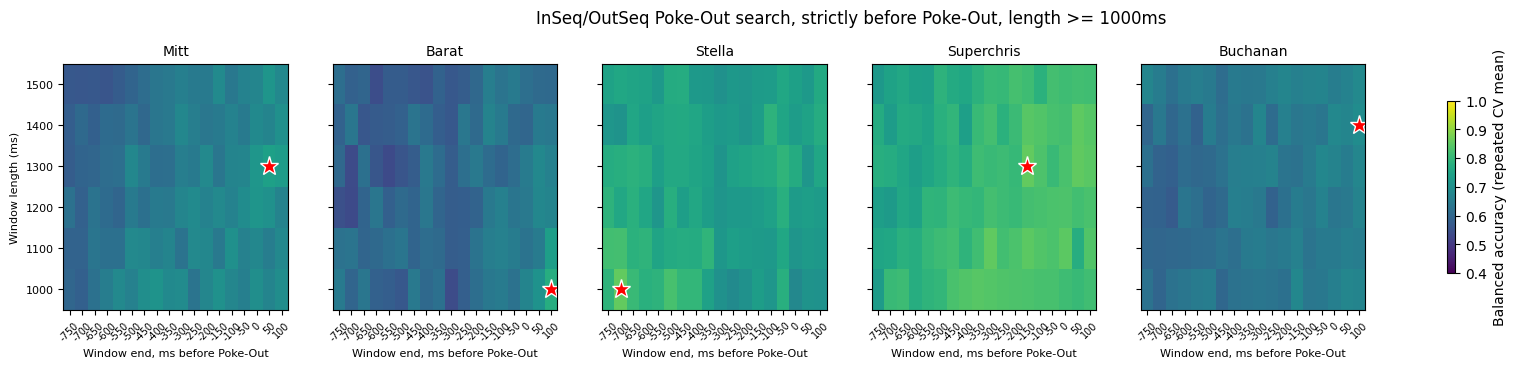

In [13]:
fig, axes = plt.subplots(1, len(SESSION_DIRS), figsize=(4.2 * len(SESSION_DIRS), 3.2), sharey=True)
for ax, sd in zip(np.atleast_1d(axes), SESSION_DIRS):
    name = sd.name
    grid = np.full((len(PREPOKEOUT_LENGTHS_MS), len(PREPOKEOUT_END_OFFSETS_MS)), np.nan)
    for i, length in enumerate(PREPOKEOUT_LENGTHS_MS):
        for j, end in enumerate(PREPOKEOUT_END_OFFSETS_MS):
            grid[i, j] = prepokeout_screening[f'prepokeout_end{end}_len{length}'][name]
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='viridis', vmin=0.4, vmax=1.0)
    ax.set_xticks(range(len(PREPOKEOUT_END_OFFSETS_MS))); ax.set_xticklabels(PREPOKEOUT_END_OFFSETS_MS, rotation=45, fontsize=7)
    ax.set_yticks(range(len(PREPOKEOUT_LENGTHS_MS))); ax.set_yticklabels(PREPOKEOUT_LENGTHS_MS, fontsize=8)
    ax.set_xlabel('Window end, ms before Poke-Out', fontsize=8)
    ax.set_title(RAT_LABELS[name], fontsize=10)
    bi, bj = np.unravel_index(np.nanargmax(grid), grid.shape)
    ax.plot(bj, bi, marker='*', color='red', markersize=14, markeredgecolor='white')
axes[0].set_ylabel('Window length (ms)', fontsize=8)
fig.colorbar(im, ax=axes.tolist(), shrink=0.7, label='Balanced accuracy (repeated CV mean)')
plt.suptitle(f'InSeq/OutSeq Poke-Out search, strictly before Poke-Out, length >= {MIN_WINDOW_LENGTH_MS}ms', y=1.05)
plt.savefig(FIG_DIR / 'prepokeout_inseq_sliding_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### Selecting the winner (maximin rule across all 5 rats, same as 2a)

In [14]:
best_name, best_score = None, -1
for name, scores in prepokeout_screening.items():
    values = list(scores.values())
    if np.any(np.isnan(values)):
        continue
    key_score = min(values)
    if key_score > best_score:
        best_score, best_name = key_score, name

winning_prepokeout_config = next(c for c in PREPOKEOUT_CANDIDATES if c['name'] == best_name)
win_start = winning_prepokeout_config['offset_ms']
win_end = winning_prepokeout_config['offset_ms'] + winning_prepokeout_config['length_ms']
print(f"Winner: {best_name} -> {winning_prepokeout_config}")
print(f"Window runs from {win_start}ms to {win_end}ms relative to Poke-Out "
      f"(i.e. ends {-win_end}ms before Poke-Out, {winning_prepokeout_config['length_ms']}ms long)")


Winner: prepokeout_end50_len1000 -> {'name': 'prepokeout_end50_len1000', 'reference': 'pokeout', 'offset_ms': -950, 'length_ms': 1000}
Window runs from -950ms to 50ms relative to Poke-Out (i.e. ends -50ms before Poke-Out, 1000ms long)


#### Full rigorous evaluation of the winning Poke-Out window

Same repeated CV + AUC + permutation-test rigor as 2a's Poke-In model -- this is what gets compared to
it directly in 2c below.


In [15]:
prepokeout_inseq_results = {}
for sd in SESSION_DIRS:
    name = sd.name
    print(f"Evaluating {RAT_LABELS[name]}...")
    X, y = get_features_for_window(sessions[name], winning_prepokeout_config, task='inseq')
    result = run_full_evaluation(X, y, class_labels=[0, 1], auc_scoring='roc_auc')
    prepokeout_inseq_results[name] = result
    print(f"  balanced_accuracy={result['balanced_accuracy']:.3f}  AUC={result['auc']:.3f}  p={result['p_value']:.4f}")


Evaluating Mitt...
  balanced_accuracy=0.687  AUC=0.775  p=0.0100
Evaluating Barat...
  balanced_accuracy=0.736  AUC=0.859  p=0.0100
Evaluating Stella...
  balanced_accuracy=0.709  AUC=0.797  p=0.0100
Evaluating Superchris...
  balanced_accuracy=0.808  AUC=0.887  p=0.0100
Evaluating Buchanan...
  balanced_accuracy=0.671  AUC=0.748  p=0.0100


#### Confusion matrices, Poke-Out InSeq/OutSeq model, one rat per figure

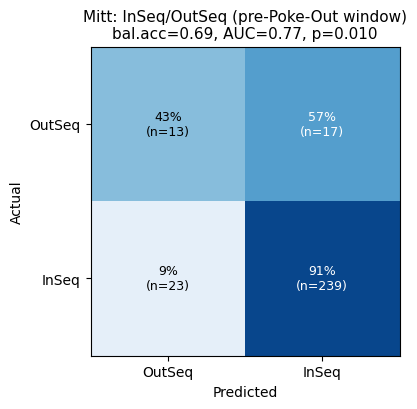

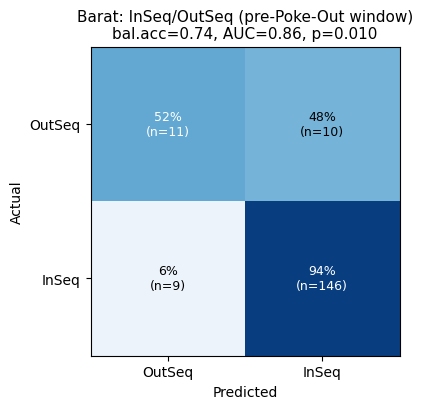

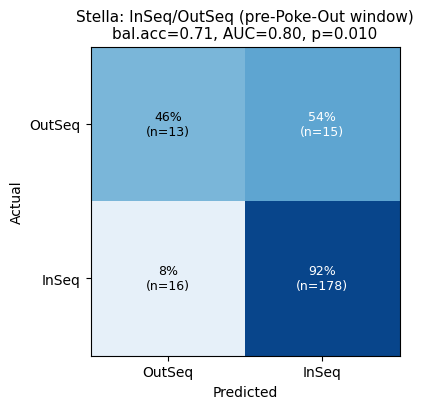

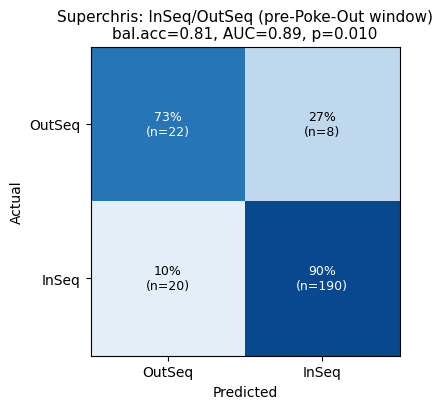

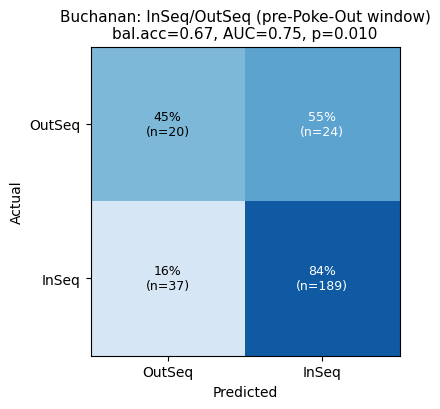

In [16]:
for name, r in prepokeout_inseq_results.items():
    fig = plot_confusion_matrix(
        r['cm_pct'], INSEQ_CLASS_NAMES,
        title=f"{RAT_LABELS[name]}: InSeq/OutSeq (pre-Poke-Out window)\nbal.acc={r['balanced_accuracy']:.2f}, AUC={r['auc']:.2f}, p={r['p_value']:.3f}",
        annotate_extra=r['cm_counts'],
    )
    fig.savefig(FIG_DIR / f'confusion_inseq_prepokeout_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


#### Combined confusion matrix -- all 5 rats, totals summed

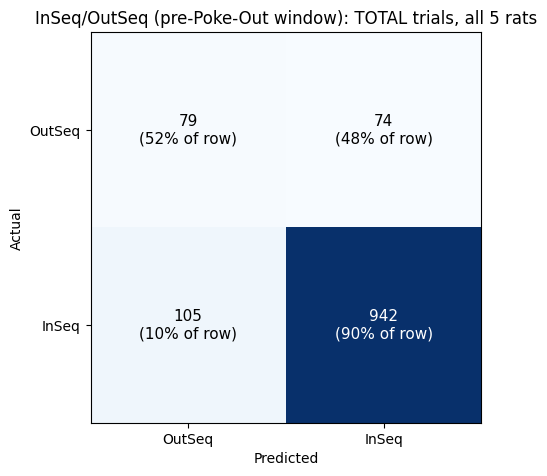

Total trials evaluated across available rats: 1200
Combined AUC (trial-weighted average across rats) 0.808


In [17]:
combined_prepokeout_counts = np.zeros((2, 2))
for r in prepokeout_inseq_results.values():
    combined_prepokeout_counts += r['cm_counts']
combined_prepokeout_pct = combined_prepokeout_counts / combined_prepokeout_counts.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(combined_prepokeout_counts, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(INSEQ_CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(INSEQ_CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('InSeq/OutSeq (pre-Poke-Out window): TOTAL trials, all 5 rats')
vmax = combined_prepokeout_counts.max()
for i in range(2):
    for j in range(2):
        val = combined_prepokeout_counts[i, j]
        ax.text(j, i, f'{int(val)}\n({combined_prepokeout_pct[i, j]:.0f}% of row)', ha='center', va='center',
                fontsize=11, color='white' if val > vmax / 2 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_inseq_prepokeout_combined_total.png', dpi=150, bbox_inches='tight')
plt.show()

combined_prepokeout_auc = sum(r['auc'] * r['cm_counts'].sum() for r in prepokeout_inseq_results.values()) / combined_prepokeout_counts.sum()
print(f"Total trials evaluated across available rats: {int(combined_prepokeout_counts.sum())}")
print(f"Combined AUC (trial-weighted average across rats) {combined_prepokeout_auc:.3f}")


### 2c. Two Final InSeq/OutSeq Models, Side by Side

2a and 2b are both genuine final models, built from windows chosen the same way (repeated-CV
screening, maximin across all 5 rats, full rigorous re-evaluation) but looking at opposite sides of the
same behavioral event, on purpose. Neither one is "the" InSeq/OutSeq model on its own -- reported
together, they answer two different questions: how early the decision becomes visible (2a), and how
strong the signal is right up to the moment it's made (2b).

For the rest of this notebook (EDA plots, interpretability), `INSEQ_WINDOW` is set to the **Poke-Out
model**, since it's the stricter, more clearly pre-decision of the two and the one that most directly
answers the concern that motivated this whole section. The Poke-In model's numbers stand on their own
in 2a above and in the table below, they are not being discarded.


In [18]:
inseq_window_comparison = pd.DataFrame({
    'Poke-In model': {RAT_LABELS[n]: r['balanced_accuracy'] for n, r in pokein_inseq_results.items()},
    'Poke-Out model': {RAT_LABELS[n]: r['balanced_accuracy'] for n, r in prepokeout_inseq_results.items()},
}).round(3)
inseq_window_comparison['difference (Poke-Out - Poke-In)'] = (
    inseq_window_comparison['Poke-Out model'] - inseq_window_comparison['Poke-In model']
).round(3)
inseq_window_comparison

,Poke-In model,Poke-Out model,difference (Poke-Out - Poke-In)
Mitt,0.679,0.687,0.008
Barat,0.726,0.736,0.010
Stella,0.769,0.709,-0.060
Superchris,0.788,0.808,0.020
Buchanan,0.691,0.671,-0.020


In [19]:
# INSEQ_WINDOW now points at the Poke-Out model's window for the rest of the notebook (EDA plots in
# Section 4, interpretability in Section 6). inseq_final_results is aliased the same way, purely so
# Sections 7/8/9 (Summary / Export / Written Summary), which were written assuming a single InSeq/OutSeq
# result, don't need to be rewritten cell by cell -- they already say what they need to say.
INSEQ_WINDOW = winning_prepokeout_config
inseq_final_results = prepokeout_inseq_results

print(f"INSEQ_WINDOW (used for EDA + interpretability from here on) = {INSEQ_WINDOW}")

INSEQ_WINDOW (used for EDA + interpretability from here on) = {'name': 'prepokeout_end50_len1000', 'reference': 'pokeout', 'offset_ms': -950, 'length_ms': 1000}


### 2d. Final Model, Odor Identity -- Poke-In Window

Odor identity is set at odor onset (Poke-In), not at the withdrawal decision, so there is no
"post-decision leakage" concern the way there is for InSeq/OutSeq -- but the same instinct still
applies: the window should sit **between Poke-In and Poke-Out**, not run on well past the point where
the rat has already left the port, since at that point the animal isn't necessarily still sampling the
odor that's being classified.

**The constraint that actually matters here, and the trade-off it creates.** Poke-Out follows Poke-In
by only about 1.3-1.4 seconds on average (see the EDA in Section 3/4). Requiring the window to both
start at or after Poke-In and be at least `MIN_WINDOW_LENGTH_MS` = 1000ms long leaves very little room
-- at most a few hundred ms of valid starting offsets before the window would start running past a
typical Poke-Out. Two ways to enforce "stay before Poke-Out" were considered:

- **Per-trial (strict):** clip each trial's own window against that trial's own recorded Poke-Out time,
  dropping trials where it would overrun. Most biologically precise, but a lot of individual trials
  would get excluded from whichever candidate they don't fit, especially any trial with an
  earlier-than-average Poke-Out.
- **Population-average ceiling (soft), used here:** treat the typical Poke-In -> Poke-Out gap
  (`TYPICAL_POKEIN_POKEOUT_GAP_MS`, the same constant the Poke-In InSeq/OutSeq search in Section 2a
  uses) as a single ceiling for every trial's `offset_ms + length_ms`. Simpler, keeps every trial in
  the pool, and is precise enough given odor identity doesn't have the same "decision already happened"
  concern that motivated the strict version for InSeq/OutSeq.

**Search grid:** offsets from 0ms in 50ms steps, lengths 1000-1500ms in 100ms steps, keeping only
combinations where `offset_ms + length_ms <= TYPICAL_POKEIN_POKEOUT_GAP_MS`. **Screening and
selection:** same repeated-CV, all-rats-maximin methodology as 2a/2b.


In [20]:
# Reuses TYPICAL_POKEIN_POKEOUT_GAP_MS from Section 2a as the ceiling, rather than a separate local
# constant, so both Poke-In-anchored searches respect exactly the same "don't run past Poke-Out" gap.
ODOR_OFFSETS_MS = list(range(0, TYPICAL_POKEIN_POKEOUT_GAP_MS - MIN_WINDOW_LENGTH_MS + 1, 50))
ODOR_LENGTHS_MS = [1000, 1100, 1200, 1300, 1400, 1500]  # every length satisfies MIN_WINDOW_LENGTH_MS
ODOR_CANDIDATES = [
    {'name': f'odor_pokein_{off}_{length}', 'reference': 'pokein', 'offset_ms': off, 'length_ms': length}
    for off in ODOR_OFFSETS_MS for length in ODOR_LENGTHS_MS
    if off + length <= TYPICAL_POKEIN_POKEOUT_GAP_MS
]
print(f"{len(ODOR_CANDIDATES)} candidates: offsets 0-{ODOR_OFFSETS_MS[-1]}ms (step 50ms) x lengths "
      f"{ODOR_LENGTHS_MS}, every one satisfying offset_ms + length_ms <= "
      f"{TYPICAL_POKEIN_POKEOUT_GAP_MS}ms")


20 candidates: offsets 0-350ms (step 50ms) x lengths [1000, 1100, 1200, 1300, 1400, 1500], every one satisfying offset_ms + length_ms <= 1350ms


#### Screening all candidates, all 5 rats, InSeq trials only

In [21]:
odor_screening = {}  # odor_screening[cfg_name][rat_name] = mean balanced_accuracy over SCREEN_CV_REPEATS folds

for sd in SESSION_DIRS:
    name = sd.name
    sess = sessions[name]
    for cfg in ODOR_CANDIDATES:
        X, y = get_features_for_window(sess, cfg, task='odor')
        if len(y) < 20 or len(np.unique(y)) < 5:
            score = np.nan
        else:
            pipe = make_pipeline()
            rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=SCREEN_CV_REPEATS, random_state=42)
            score = cross_val_score(pipe, X, y, cv=rskf, scoring='balanced_accuracy').mean()
        odor_screening.setdefault(cfg['name'], {})[name] = score
    print(f"{RAT_LABELS[name]} screened ({len(ODOR_CANDIDATES)}/{len(ODOR_CANDIDATES)} candidates)")

print("\nScreening complete.")

Mitt screened (20/20 candidates)
Barat screened (20/20 candidates)
Stella screened (20/20 candidates)
Superchris screened (20/20 candidates)
Buchanan screened (20/20 candidates)

Screening complete.


#### Where is the Odor Identity signal strongest, within the Poke-In -> Poke-Out gap?

The candidate grid is much narrower here than 2a/2b (by construction -- see the trade-off above), so
rather than a heatmap this just plots balanced accuracy against offset, one line per length, one panel
per rat. The red star marks each rat's individual best.


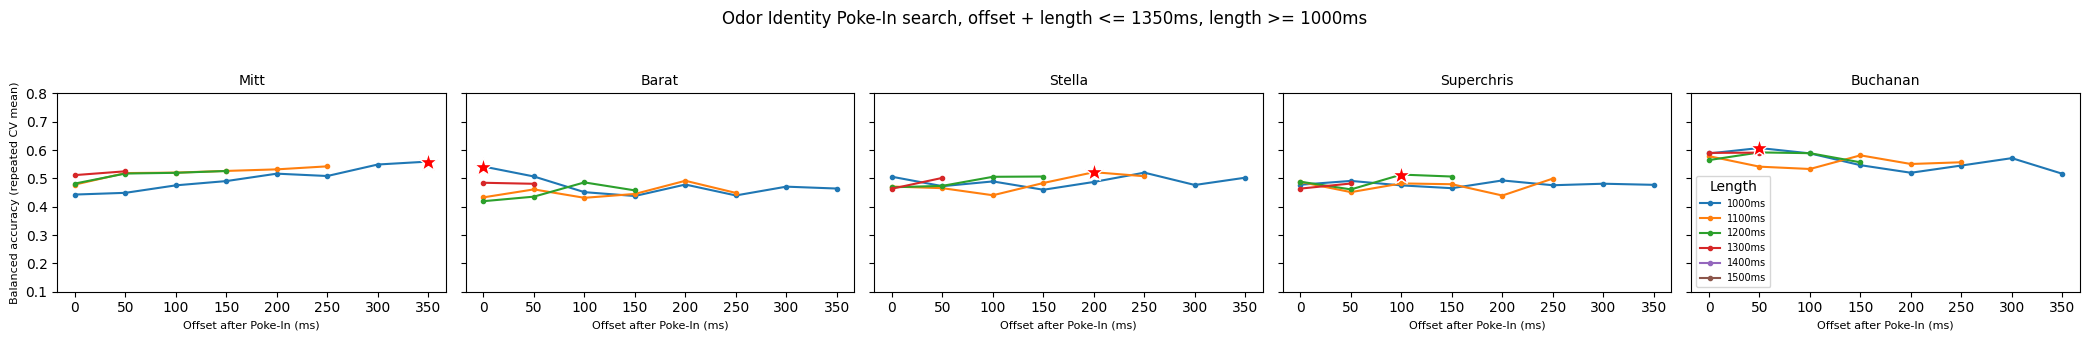

In [22]:
fig, axes = plt.subplots(1, len(SESSION_DIRS), figsize=(4.2 * len(SESSION_DIRS), 3.2), sharey=True)
for ax, sd in zip(np.atleast_1d(axes), SESSION_DIRS):
    name = sd.name
    best_overall, best_pt = -1, None
    for length in ODOR_LENGTHS_MS:
        offs = [off for off in ODOR_OFFSETS_MS if off + length <= TYPICAL_POKEIN_POKEOUT_GAP_MS]
        scores = [odor_screening[f'odor_pokein_{off}_{length}'][name] for off in offs]
        ax.plot(offs, scores, marker='o', markersize=3, label=f'{length}ms')
        for off, s in zip(offs, scores):
            if not np.isnan(s) and s > best_overall:
                best_overall, best_pt = s, (off, s)
    if best_pt is not None:
        ax.plot(*best_pt, marker='*', color='red', markersize=14, markeredgecolor='white', zorder=5)
    ax.set_xlabel('Offset after Poke-In (ms)', fontsize=8)
    ax.set_title(RAT_LABELS[name], fontsize=10)
    ax.set_ylim(0.1, 0.8)
axes[0].set_ylabel('Balanced accuracy (repeated CV mean)', fontsize=8)
axes[-1].legend(title='Length', fontsize=7)
plt.suptitle(f'Odor Identity Poke-In search, offset + length <= {TYPICAL_POKEIN_POKEOUT_GAP_MS}ms, length >= {MIN_WINDOW_LENGTH_MS}ms', y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'odor_pokein_sliding_search.png', dpi=150, bbox_inches='tight')
plt.show()

#### Selecting the winner (maximin rule across all 5 rats, same as 2a/2b)

In [23]:
best_name, best_score = None, -1
for name, scores in odor_screening.items():
    values = list(scores.values())
    if np.any(np.isnan(values)):
        continue
    key_score = min(values)
    if key_score > best_score:
        best_score, best_name = key_score, name

winning_odor_config = next(c for c in ODOR_CANDIDATES if c['name'] == best_name)
print(f"Winner: {best_name} -> {winning_odor_config}")

# ODOR_WINDOW now points at this search's winner for the rest of the notebook (Section 4's EDA plots,
# Section 5's Final Model 2 evaluation, and Section 6's interpretability all read this name).
ODOR_WINDOW = winning_odor_config
print(f"ODOR_WINDOW (used for the rest of the notebook) = {ODOR_WINDOW}")


Winner: odor_pokein_100_1200 -> {'name': 'odor_pokein_100_1200', 'reference': 'pokein', 'offset_ms': 100, 'length_ms': 1200}
ODOR_WINDOW (used for the rest of the notebook) = {'name': 'odor_pokein_100_1200', 'reference': 'pokein', 'offset_ms': 100, 'length_ms': 1200}


### 2e. Overfitting Safeguard -- Is the Winning Window Actually Stable?

**The risk.** Each search above screens 20-45 candidate windows and picks whichever one scores highest.
Even with the repeated-CV averaging from `SCREEN_CV_REPEATS`, picking the best of many noisy estimates
can look better than it really is -- this is the "winner's curse": with enough candidates, *something*
will look good on any particular CV split just by chance, and that something gets crowned the winner.
The full rigorous re-evaluation above (repeated CV, permutation test) reports how good the winner looks
once it's already been picked, but it doesn't by itself tell us whether a *different* CV shuffle would
have picked a meaningfully different window.

**What a true nested cross-validation would do, and why it isn't used here.** The textbook fix is
nested CV: hold out a slice of data, redo the entire search using only the rest, then score the
re-selected winner on the held-out slice, repeated across several outer folds. With only 5 rats and a
selection rule that needs every rat present in each fold, there is not enough independent
data to hold a meaningful slice out and still run the maximin rule properly -- a "nested CV" here would
mostly just be measuring how sensitive the result is to removing one of five rats, which is a different
question.

**What this section does instead.** It reruns the *entire* screen-and-select procedure for each search
several more times, changing only the CV random seed each time, and checks two things: (1) does the
same window (or a close neighbor) keep winning, and (2) does its score stay roughly the same across
reruns? A selection that keeps landing on the same window with a stable score is one we can trust; a
selection that jumps between very different windows depending on the CV shuffle is a sign that the
reported winner is partly an artifact of the fold split, even though its own headline number will still
look good.


In [24]:
def rerun_maximin_selection(candidates, sessions_dict, task, seed, min_class_count=2):
    """One full screen-then-maximin-select pass at a given CV random_state -- the same procedure used
    in 2a/2b/2d above, just refactored into a function so it can be repeated with different seeds."""
    screen = {}
    for sd_name, sess in sessions_dict.items():
        for cfg in candidates:
            X, y = get_features_for_window(sess, cfg, task=task)
            if len(y) < 20 or len(np.unique(y)) < min_class_count:
                score = np.nan
            else:
                pipe = make_pipeline()
                skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
                score = cross_val_score(pipe, X, y, cv=skf, scoring='balanced_accuracy').mean()
            screen.setdefault(cfg['name'], {})[sd_name] = score
    best_name, best_score = None, -1
    for name, scores in screen.items():
        values = list(scores.values())
        if np.any(np.isnan(values)):
            continue
        key_score = min(values)
        if key_score > best_score:
            best_score, best_name = key_score, name
    return best_name, best_score


STABILITY_SEEDS = [1, 2, 3, 4, 5]  # different from the seed=42 used for the main screen above

stability_results = {}
for search_label, candidates, task in [
    ('Poke-In InSeq/OutSeq (2a)', POKEIN_CANDIDATES, 'inseq'),
    ('Poke-Out InSeq/OutSeq (2b)', PREPOKEOUT_CANDIDATES, 'inseq'),
    ('Odor Identity (2d)', ODOR_CANDIDATES, 'odor'),
]:
    print(f"Stability check: {search_label}...")
    runs = [rerun_maximin_selection(candidates, sessions, task, seed) for seed in STABILITY_SEEDS]
    stability_results[search_label] = runs
    for seed, (name, score) in zip(STABILITY_SEEDS, runs):
        print(f"  seed={seed}: winner={name}  score={score:.3f}")

print("\nDone.")

Stability check: Poke-In InSeq/OutSeq (2a)...


KeyboardInterrupt: 

In [ ]:
stability_rows = []
for search_label, runs in stability_results.items():
    names = [n for n, s in runs]
    scores = np.array([s for n, s in runs])
    most_common = max(set(names), key=names.count)
    stability_rows.append({
        'search': search_label,
        'most common winner': most_common,
        'agreement (of %d reruns)' % len(runs): f"{names.count(most_common)}/{len(runs)}",
        'score mean': round(scores.mean(), 3),
        'score std': round(scores.std(), 3),
    })
stability_table = pd.DataFrame(stability_rows).set_index('search')
stability_table

**Reading this table.** High agreement (most reruns picking the same or a neighboring window) plus a
low score standard deviation means the search above found a genuinely reliable window, not a fold-split
artifact -- treat the results in 2a/2b/2d as solid. If a search instead shows low agreement or a large
score spread here, that specific model's headline accuracy should be reported with real caution, and
is a good candidate for shrinking its candidate grid or gathering more data before trusting it further.


## 3. Data & Task Overview (EDA)

Before looking at any model output: how much data does each rat actually contribute, and how
imbalanced are the two tasks? Both matter for interpreting the results below (e.g. `balanced_accuracy`
is used everywhere specifically because InSeq/OutSeq is roughly 90/10). Across all 5 rats combined, the
final InSeq/OutSeq model below is evaluated on **1,200 trials total: 153 OutSeq and 1,047 InSeq**
(12.75% OutSeq) -- consistent with the per-rat imbalance shown here.


In [25]:
# sessions already loaded above (moved ahead of Section 2, which needs it first)
print("Loaded:", list(sessions.keys()))


Loaded: ['080718_mitt', '081106_barat', '090212_stella', '090212_superchris', '090420_buchanan']


In [26]:
rows = []
for name, sess in sessions.items():
    labels = sess['labels']
    n_trials = len(labels['trial_idx'])
    n_inseq = int((labels['inseq_outseq'] == 1).sum())
    n_outseq = int((labels['inseq_outseq'] == 0).sum())
    odor_counts = np.bincount(labels['odor_id'][labels['inseq_outseq'] == 1], minlength=5)
    duration_min = (sess['timebin'][-1] - sess['timebin'][0]) / 60
    rows.append({
        'rat': RAT_LABELS[name], 'session': name, 'fs_hz': round(sess['fs'], 1),
        'duration_min': round(duration_min, 1), 'n_trials': n_trials,
        'n_inseq': n_inseq, 'n_outseq': n_outseq,
        'pct_outseq': round(100 * n_outseq / n_trials, 1),
        'odor_A': odor_counts[0], 'odor_B': odor_counts[1], 'odor_C': odor_counts[2],
        'odor_D': odor_counts[3], 'odor_E': odor_counts[4],
    })
eda_table = pd.DataFrame(rows).set_index('rat')
eda_table


,session,fs_hz,duration_min,n_trials,n_inseq,n_outseq,pct_outseq,odor_A,odor_B,odor_C,odor_D,odor_E
rat,,,,,,,,,,,,
Mitt,080718_mitt,714.1,122.7,292,262,30,10.3,79,59,50,41,33
Barat,081106_barat,769.5,81.3,176,155,21,11.9,49,34,25,26,21
Stella,090212_stella,958.4,54.6,222,194,28,12.6,58,45,33,32,26
Superchris,090212_superchris,1000.0,51.1,240,210,30,12.5,56,50,39,34,31
Buchanan,090420_buchanan,759.5,71.6,270,226,44,16.3,76,43,30,43,34


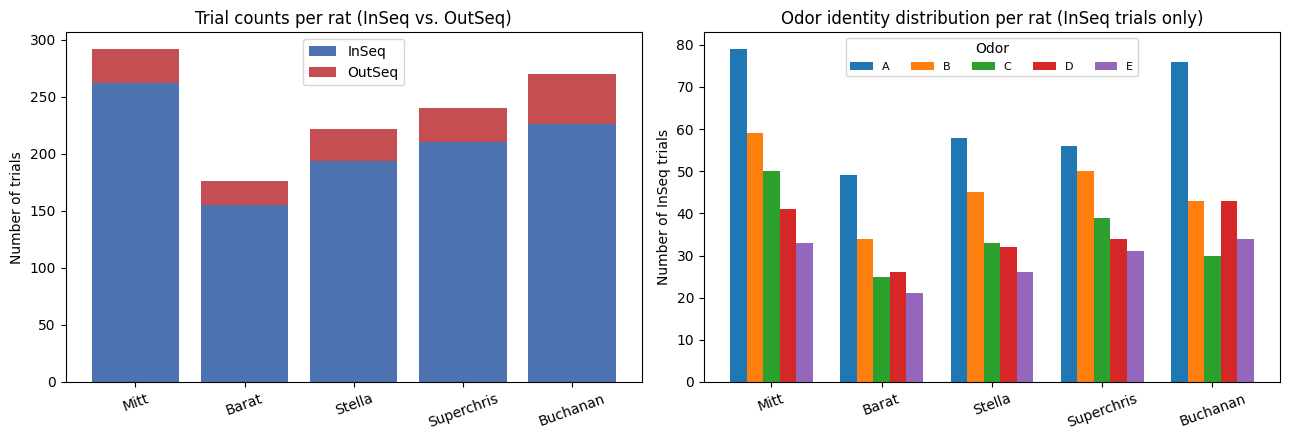

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rats = eda_table.index.tolist()
x = np.arange(len(rats))

axes[0].bar(x, eda_table['n_inseq'], label='InSeq', color='#4C72B0')
axes[0].bar(x, eda_table['n_outseq'], bottom=eda_table['n_inseq'], label='OutSeq', color='#C44E52')
axes[0].set_xticks(x); axes[0].set_xticklabels(rats, rotation=20)
axes[0].set_ylabel('Number of trials')
axes[0].set_title('Trial counts per rat (InSeq vs. OutSeq)')
axes[0].legend()

odor_cols = ['odor_A', 'odor_B', 'odor_C', 'odor_D', 'odor_E']
width = 0.15
for i, col in enumerate(odor_cols):
    axes[1].bar(x + (i - 2) * width, eda_table[col], width, label=col.replace('odor_', ''))
axes[1].set_xticks(x); axes[1].set_xticklabels(rats, rotation=20)
axes[1].set_ylabel('Number of InSeq trials')
axes[1].set_title('Odor identity distribution per rat (InSeq trials only)')
axes[1].legend(title='Odor', ncol=5, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_trial_counts.png', dpi=150)
plt.show()


**Reading this:** InSeq/OutSeq is imbalanced by task design (roughly 85-90% InSeq), which is why
every model below uses `class_weight='balanced'` and reports **balanced accuracy** rather than plain
accuracy. Odor identity (A-E) is close to evenly split within InSeq trials, as expected from the task.
This imbalance is also why a single overall "% correct" number would be misleading on its own, and why
every result in this notebook is reported as balanced accuracy plus AUC plus a permutation-test p-value
rather than accuracy alone.


## 4. What Does the Brain Data Actually Look Like?

Before trusting any classifier number, it helps to just look at the signal it's built from. This
section shows: (1) raw LFP traces around one real trial, with the two final classification windows
drawn on top so it's clear exactly what slice of data each model actually sees, (1b) that same trace
broken apart into its individual frequency bands ("brainwaves") -- delta, theta, beta, low-gamma,
high-gamma -- since band power is the only thing the model ever sees, not the raw trace, (2) average
power per frequency band, InSeq vs. OutSeq.


### 4a. Raw LFP traces around one trial, with both final windows overlaid

**Why is the InSeq/OutSeq window shown here anchored to Poke-Out, and mostly *before* it?**
This is the Section 2b window -- the result of a sliding search constrained so every candidate ends at
or before Poke-Out, so a positive InSeq/OutSeq result can only be explained by activity that preceded
the rat's withdrawal, not by the withdrawal movement itself. (The Poke-In model from Section 2a is a
separate, independently-searched window -- its own numbers are reported in Section 2a, not shown here.)

To make each window easier to actually look at, it's shown below as **two separate figures**, each
zoomed to its own reference event (rather than one crowded timeline where the later window is squeezed
off to the side):


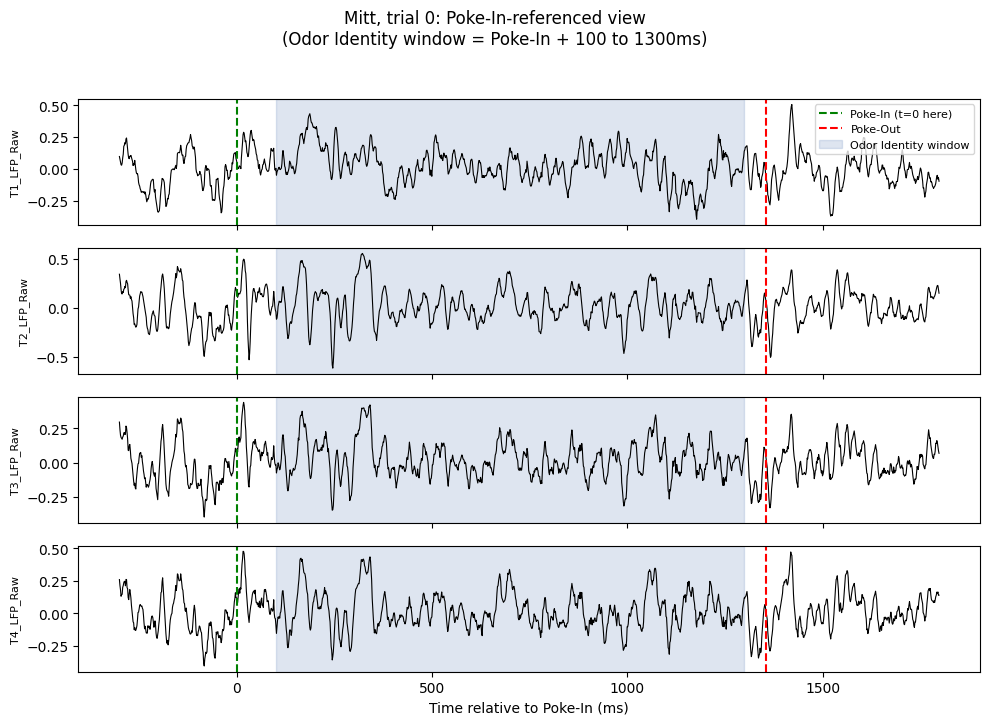

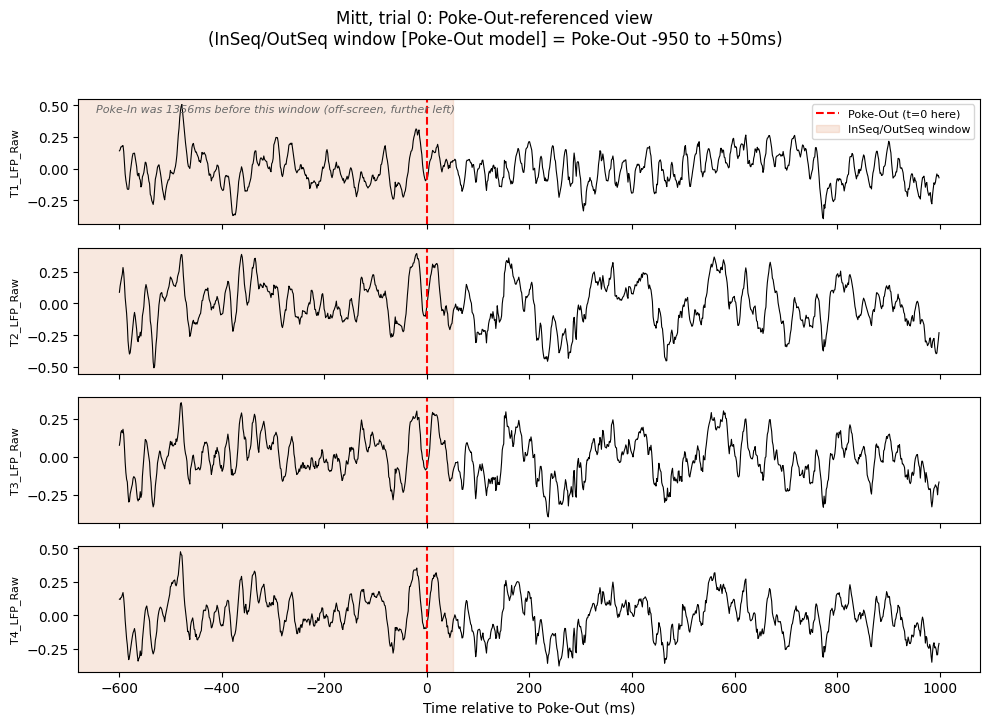

In [28]:
example_name = '080718_mitt' if '080718_mitt' in sessions else list(sessions.keys())[0]
sess = sessions[example_name]
trial_i = 0  # first trial with a valid Poke-Out
while sess['pokeout_idx'][trial_i] < 0:
    trial_i += 1

t_in = sess['labels']['trial_idx'][trial_i]
t_out = sess['pokeout_idx'][trial_i]
fs = sess['fs']
gap_ms = (sess['timebin'][t_out] - sess['timebin'][t_in]) * 1000
channel_names = [sess['lfp_keys'][ch] for ch in range(4)]  # real electrode names, not 'ch 0'/'ch 1'/...

# ---- Figure A: Poke-In-referenced view (Odor Identity window) ----
win_start_a = t_in - int(0.3 * fs)
win_end_a = t_in + int(1.8 * fs)
time_a = (np.arange(win_start_a, win_end_a) - t_in) / fs * 1000

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, ch, chname in zip(axes, range(4), channel_names):
    ax.plot(time_a, sess['lfp_data'][ch, win_start_a:win_end_a], lw=0.8, color='black')
    ax.axvline(0, color='green', linestyle='--', label='Poke-In (t=0 here)' if ch == 0 else None)
    if gap_ms <= time_a[-1]:
        ax.axvline(gap_ms, color='red', linestyle='--', label='Poke-Out' if ch == 0 else None)
    ax.axvspan(ODOR_WINDOW['offset_ms'], ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms'],
               color='#4C72B0', alpha=0.18, label='Odor Identity window' if ch == 0 else None)
    ax.set_ylabel(chname, fontsize=8)
axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time relative to Poke-In (ms)')
odor_end_ms = ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms']
fig.suptitle(f"{RAT_LABELS[example_name]}, trial {trial_i}: Poke-In-referenced view\n"
             f"(Odor Identity window = Poke-In + {ODOR_WINDOW['offset_ms']} to {odor_end_ms}ms)", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_lfp_pokein_view.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure B: Poke-Out-referenced view (InSeq/OutSeq window) ----
win_start_b = t_out - int(0.6 * fs)
win_end_b = t_out + int(1.0 * fs)
time_b = (np.arange(win_start_b, win_end_b) - t_out) / fs * 1000
poke_in_rel_to_out_ms = -gap_ms  # where Poke-In would sit on this Poke-Out-relative axis

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, ch, chname in zip(axes, range(4), channel_names):
    ax.plot(time_b, sess['lfp_data'][ch, win_start_b:win_end_b], lw=0.8, color='black')
    ax.axvline(0, color='red', linestyle='--', label='Poke-Out (t=0 here)' if ch == 0 else None)
    if poke_in_rel_to_out_ms >= time_b[0]:
        ax.axvline(poke_in_rel_to_out_ms, color='green', linestyle='--', label='Poke-In' if ch == 0 else None)
    ax.axvspan(INSEQ_WINDOW['offset_ms'], INSEQ_WINDOW['offset_ms'] + INSEQ_WINDOW['length_ms'],
               color='#DD8452', alpha=0.18, label='InSeq/OutSeq window' if ch == 0 else None)
    ax.set_ylabel(chname, fontsize=8)
axes[0].legend(loc='upper right', fontsize=8)
if poke_in_rel_to_out_ms < time_b[0]:
    axes[0].annotate(f'Poke-In was {gap_ms:.0f}ms before this window (off-screen, further left)',
                      xy=(0.02, 0.90), xycoords='axes fraction', fontsize=8, style='italic', color='dimgray')
axes[-1].set_xlabel('Time relative to Poke-Out (ms)')
inseq_start_ms = INSEQ_WINDOW['offset_ms']
inseq_end_ms = INSEQ_WINDOW['offset_ms'] + INSEQ_WINDOW['length_ms']
fig.suptitle(f"{RAT_LABELS[example_name]}, trial {trial_i}: Poke-Out-referenced view\n"
             f"(InSeq/OutSeq window [Poke-Out model] = Poke-Out {inseq_start_ms:+d} to {inseq_end_ms:+d}ms)", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_lfp_pokeout_view.png', dpi=150, bbox_inches='tight')
plt.show()


### 4b. The same trial, split into its frequency bands ("brainwaves")

The model never sees the raw trace above -- it sees **power in five frequency bands**, per channel.
This cell makes that concrete in two ways: first, it band-pass filters the same example trial into
delta, theta, beta, low-gamma, and high-gamma and stacks them underneath the raw signal, each on **its
own y-axis scale** (labeled with real units) since the bands are not comparable in raw amplitude --
theta's oscillation is naturally much bigger than high-gamma's, so a shared axis would flatten the
faster bands to what looks like a flat line. Second, it shows all five bands **overlaid on one shared
axis**, after standardizing each one (mean 0, standard deviation 1) so they're visually comparable in
timing and shape even though their raw sizes are wildly different -- the y-axis there is explicitly
labeled as standardized units, not raw voltage, so it can't be mistaken for the first figure.

Two things to look for: (1) theta (4-12 Hz) is the band with by far the largest, most regular
oscillation in raw hippocampal LFP -- that's not a modeling choice, it's a property of the tissue, and
it's why theta shows up so often in hippocampus research generally; (2) the higher bands (beta,
low/high-gamma) look like noisy, low-amplitude ripples on top of theta rather than clean oscillations
by eye -- which is exactly why band *power* (not the raw waveform) is the feature that gets fed into
the model.


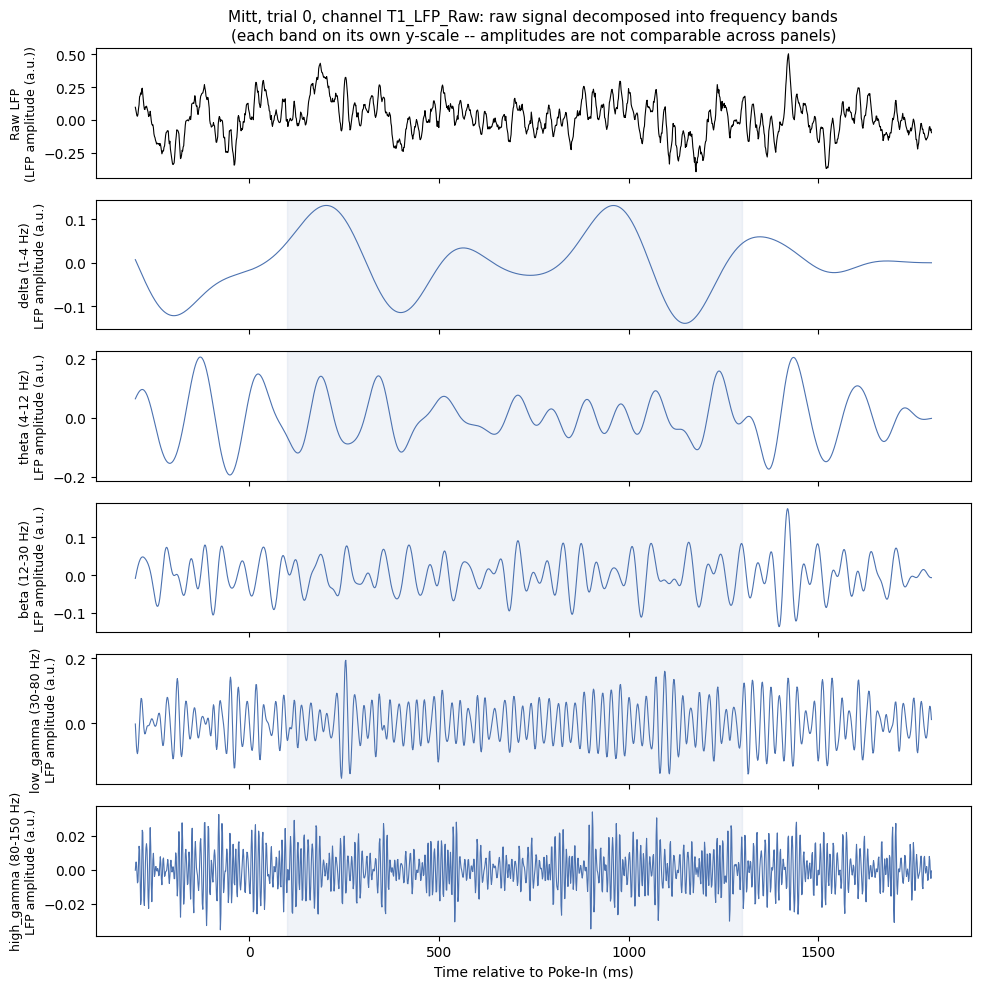

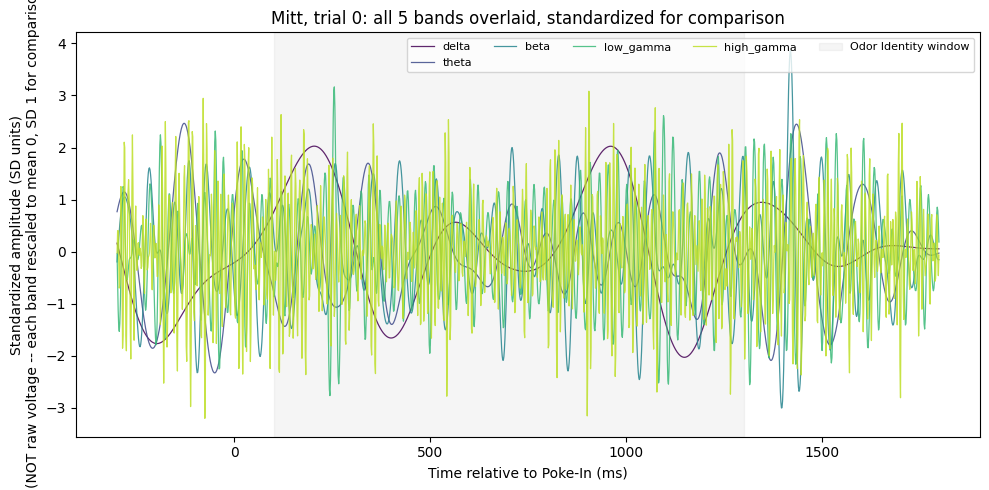

In [29]:
from scipy.signal import butter, filtfilt

def bandpass_filter(sig_1d, fs, low, high, order=4):
    """Zero-phase Butterworth band-pass, clipped to stay below Nyquist."""
    nyq = fs / 2
    low_n = max(low / nyq, 1e-4)
    high_n = min(high / nyq, 0.999)
    b, a = butter(order, [low_n, high_n], btype='band')
    return filtfilt(b, a, sig_1d)

# Reuse the same example trial / channel-0 trace as Figure A above (Poke-In-referenced window)
brainwave_channel = 0  # first electrode, just for illustration
raw_trace = sess['lfp_data'][brainwave_channel, win_start_a:win_end_a]
raw_unit = 'LFP amplitude (a.u.)'  # matches whatever unit the raw .lfp files are stored in

# ---- Figure 1: stacked, each band on its OWN y-axis scale ----
# Each band keeps its own scale deliberately -- theta's oscillation amplitude is typically much
# larger than high-gamma's, so a shared y-axis would make the faster bands look like flat lines
# near zero even when there's real signal in them.
fig, axes = plt.subplots(len(BANDS) + 1, 1, figsize=(10, 10), sharex=True)

axes[0].plot(time_a, raw_trace, color='black', lw=0.8)
axes[0].set_ylabel(f'Raw LFP\n({raw_unit})', fontsize=9)
axes[0].set_title(f'{RAT_LABELS[example_name]}, trial {trial_i}, channel {channel_names[brainwave_channel]}: '
                   'raw signal decomposed into frequency bands\n(each band on its own y-scale -- amplitudes are not comparable across panels)', fontsize=11)

filtered_by_band = {}
for ax, (band_name, (lo, hi)) in zip(axes[1:], BANDS.items()):
    filtered = bandpass_filter(raw_trace, fs, lo, hi)
    filtered_by_band[band_name] = filtered
    ax.plot(time_a, filtered, lw=0.8, color='#4C72B0')
    ax.set_ylabel(f'{band_name} ({lo}-{hi} Hz)\n{raw_unit}', fontsize=9)
    ax.axvspan(ODOR_WINDOW['offset_ms'], ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms'],
               color='#4C72B0', alpha=0.08)

axes[-1].set_xlabel('Time relative to Poke-In (ms)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lfp_bands_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Figure 2: all 5 bands overlaid on ONE axis, standardized so they're comparable ----
# Standardizing (subtract mean, divide by SD) makes this about relative TIMING and SHAPE, not
# absolute size -- so the y-axis is now unitless (standard-deviation units), not raw amplitude.
# This is purely a visualization choice; the model itself never sees standardized waveforms like
# this, it sees standardized *band power* (a single number per band per trial, see Section 6).
fig, ax = plt.subplots(figsize=(10, 5))
band_colors = plt.cm.viridis(np.linspace(0, 0.9, len(BANDS)))
for color, (band_name, filtered) in zip(band_colors, filtered_by_band.items()):
    standardized = (filtered - filtered.mean()) / filtered.std()
    ax.plot(time_a, standardized, lw=0.9, color=color, label=band_name, alpha=0.85)
ax.axvspan(ODOR_WINDOW['offset_ms'], ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms'],
           color='gray', alpha=0.08, label='Odor Identity window')
ax.set_xlabel('Time relative to Poke-In (ms)')
ax.set_ylabel('Standardized amplitude (SD units)\n(NOT raw voltage -- each band rescaled to mean 0, SD 1 for comparison)')
ax.set_title(f'{RAT_LABELS[example_name]}, trial {trial_i}: all 5 bands overlaid, standardized for comparison')
ax.legend(ncol=5, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lfp_bands_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


### 4c. Average power per frequency band: InSeq vs. OutSeq

Using the final InSeq/OutSeq window (Poke-Out model, from Section 2b), averaged across channels and
trials, per rat.


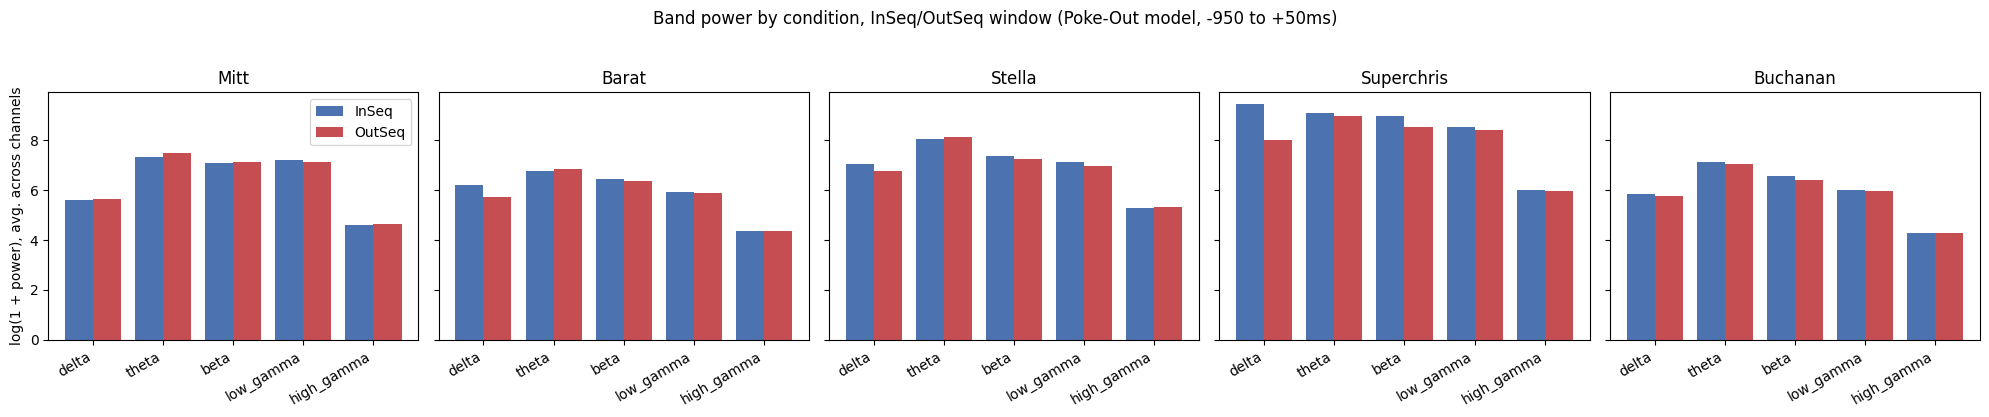

In [30]:
fig, axes = plt.subplots(1, len(sessions), figsize=(4 * len(sessions), 4), sharey=True)
band_names = list(BANDS.keys())

for ax, (name, sess) in zip(np.atleast_1d(axes), sessions.items()):
    X, y = get_features_for_window(sess, INSEQ_WINDOW, task='inseq')
    n_channels = X.shape[1] // len(band_names)
    X_band_avg = X.reshape(len(X), n_channels, len(band_names)).mean(axis=1)
    inseq_mean = X_band_avg[y == 1].mean(axis=0)
    outseq_mean = X_band_avg[y == 0].mean(axis=0)

    xw = np.arange(len(band_names))
    ax.bar(xw - 0.2, inseq_mean, width=0.4, label='InSeq', color='#4C72B0')
    ax.bar(xw + 0.2, outseq_mean, width=0.4, label='OutSeq', color='#C44E52')
    ax.set_xticks(xw); ax.set_xticklabels(band_names, rotation=30, ha='right')
    ax.set_title(RAT_LABELS[name])

axes[0].set_ylabel('log(1 + power), avg. across channels')
axes[0].legend()
plt.suptitle(f"Band power by condition, InSeq/OutSeq window (Poke-Out model, "
             f"{INSEQ_WINDOW['offset_ms']:+d} to {INSEQ_WINDOW['offset_ms'] + INSEQ_WINDOW['length_ms']:+d}ms)", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'band_power_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Final Model, Odor Identity

**Training window:** set by the Section 2d search above (`ODOR_WINDOW`) -- Poke-In referenced,
constrained to stay within the typical Poke-In -> Poke-Out gap and to be at least
`MIN_WINDOW_LENGTH_MS` long, InSeq trials only, 5-way classification (odors A-E). This is a
completely separate window from either InSeq/OutSeq model in Section 2 -- different reference logic,
independently searched, and not assumed to match either one's length.


In [31]:
odor_final_results = {}

for sd in SESSION_DIRS:
    name = sd.name
    print(f"Training Odor Identity model: {RAT_LABELS[name]}...")
    X, y = get_features_for_window(sessions[name], ODOR_WINDOW, task='odor')
    result = run_full_evaluation(X, y, class_labels=[0, 1, 2, 3, 4], auc_scoring='roc_auc_ovr')
    odor_final_results[name] = result
    print(f"  balanced_accuracy={result['balanced_accuracy']:.3f}  AUC(ovr)={result['auc']:.3f}  p={result['p_value']:.4f}")

print("\nAll Odor Identity models trained.")


Training Odor Identity model: Mitt...
  balanced_accuracy=0.519  AUC(ovr)=0.808  p=0.0100
Training Odor Identity model: Barat...
  balanced_accuracy=0.477  AUC(ovr)=0.777  p=0.0100
Training Odor Identity model: Stella...
  balanced_accuracy=0.503  AUC(ovr)=0.809  p=0.0100
Training Odor Identity model: Superchris...
  balanced_accuracy=0.511  AUC(ovr)=0.806  p=0.0100
Training Odor Identity model: Buchanan...
  balanced_accuracy=0.578  AUC(ovr)=0.854  p=0.0100

All Odor Identity models trained.


In [32]:
summary_rows = []
for name, r in odor_final_results.items():
    summary_rows.append({'rat': RAT_LABELS[name], 'balanced_accuracy': round(r['balanced_accuracy'], 3),
                          'auc_ovr': round(r['auc'], 3), 'p_value': round(r['p_value'], 4)})
odor_summary = pd.DataFrame(summary_rows).set_index('rat')
odor_summary


,balanced_accuracy,auc_ovr,p_value
rat,,,
Mitt,0.519,0.808,0.01
Barat,0.477,0.777,0.01
Stella,0.503,0.809,0.01
Superchris,0.511,0.806,0.01
Buchanan,0.578,0.854,0.01


### 5a. Confusion matrices, one rat per figure (for slides)

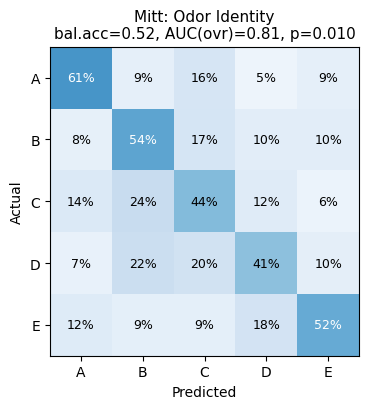

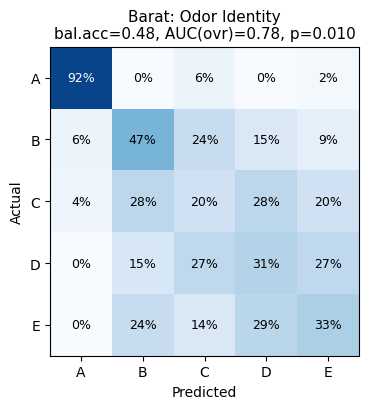

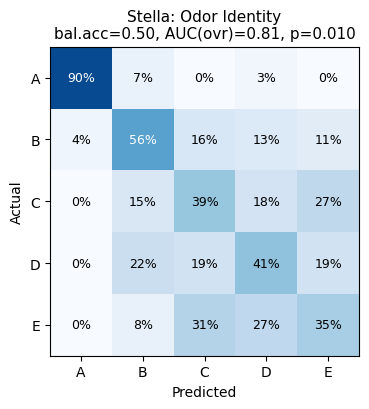

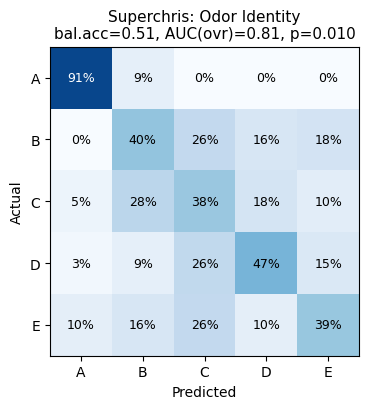

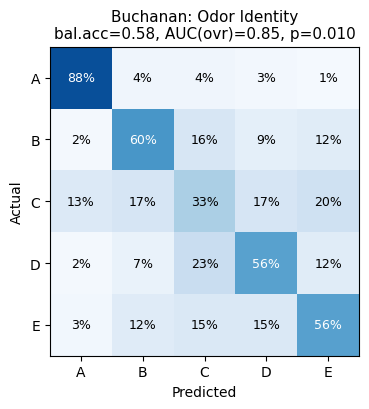

In [33]:
ODOR_CLASS_NAMES = ['A', 'B', 'C', 'D', 'E']

for name, r in odor_final_results.items():
    fig = plot_confusion_matrix(
        r['cm_pct'], ODOR_CLASS_NAMES,
        title=f"{RAT_LABELS[name]}: Odor Identity\nbal.acc={r['balanced_accuracy']:.2f}, AUC(ovr)={r['auc']:.2f}, p={r['p_value']:.3f}",
    )
    fig.savefig(FIG_DIR / f'confusion_odor_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


### 5b. Combined confusion matrix -- all 5 rats, totals summed

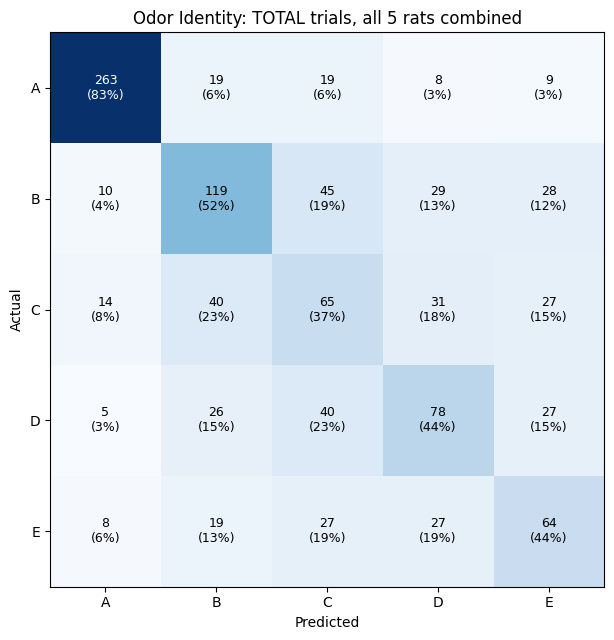

Total InSeq trials evaluated across all rats: 1047
Total InSeq trials evaluated across all rats: 1047
Combined AUC (trial-weighted average across rats, one-vs-rest) 0.813


In [34]:
combined_odor_counts = np.zeros((5, 5))
for r in odor_final_results.values():
    combined_odor_counts += r['cm_counts']

combined_odor_pct = combined_odor_counts / combined_odor_counts.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6.5, 6.5))
im = ax.imshow(combined_odor_counts, cmap='Blues')
ax.set_xticks(range(5)); ax.set_xticklabels(ODOR_CLASS_NAMES)
ax.set_yticks(range(5)); ax.set_yticklabels(ODOR_CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Odor Identity: TOTAL trials, all 5 rats combined')
vmax = combined_odor_counts.max()
for i in range(5):
    for j in range(5):
        val = combined_odor_counts[i, j]
        ax.text(j, i, f'{int(val)}\n({combined_odor_pct[i, j]:.0f}%)', ha='center', va='center',
                fontsize=9, color='white' if val > vmax / 2 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_odor_combined_total.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total InSeq trials evaluated across all rats: {int(combined_odor_counts.sum())}")

combined_odor_auc = sum(r['auc'] * r['cm_counts'].sum() for r in odor_final_results.values()) / combined_odor_counts.sum()
print(f"Total InSeq trials evaluated across all rats: {int(combined_odor_counts.sum())}")
print(f"Combined AUC (trial-weighted average across rats, one-vs-rest) {combined_odor_auc:.3f}")


## 6. Interpretability: Which Frequency Band Is Actually Driving Each Model?

Everything above answers "how well does the model do." This section answers the more important
question for this project: **why** -- which frequency band's logistic-regression coefficient (beta) is
doing the most work, and in which direction? Because every feature was standardized (`StandardScaler`)
before fitting, each beta is already in an interpretable unit: **one beta = the change in log-odds of
the outcome per one-standard-deviation increase in that band's power**, holding the other bands fixed.
That standardization is also what makes bands comparable to each other in the first place -- raw delta
power and raw high-gamma power live on completely different scales, but their *standardized* betas do
not.

**From log-odds to something a non-statistician can picture:** a beta of $b$ means each 1-SD increase
in that band's power multiplies the *odds* of the outcome by $e^{b}$ (e.g. $b=2 \Rightarrow e^{2}
\approx 7.4\times$ the odds). To turn that into a probability, pick a reference probability $p_0$
(e.g. 0.5, "no information yet"), convert it to log-odds ($\text{logit}(p_0) = \ln\frac{p_0}{1-p_0}$),
add $b$, and convert back: $p_1 = \frac{1}{1+e^{-(\text{logit}(p_0)+b)}}$. Concretely, starting from
$p_0=0.5$ (logit $=0$) and a beta of 2: $p_1 = \frac{1}{1+e^{-2}} \approx 0.88$ -- a 1-SD jump in that
band's power would move the model from a coin flip to an 88% call. The sign of beta matters as much as
its size: positive means higher power in that band pushes toward the positive class (InSeq, or a given
odor), negative means higher power pushes away from it.

**Three models are interpreted below, separately.** InSeq/OutSeq now has two genuinely different final
models (Section 2a's Poke-In model and Section 2b's Poke-Out model, `INSEQ_WINDOW` points at the
Poke-Out one per Section 2c), plus Odor Identity (`ODOR_WINDOW`, Section 2d). Each gets its own betas,
its own bar chart, and its own place in the ranking and heatmap below -- the Poke-In model's betas are
not assumed to look like the Poke-Out model's just because they're both InSeq/OutSeq.

**What follows:** for each task/model, the final pipeline is refit on each rat's full dataset (same
`StandardScaler` + `LogisticRegression(class_weight='balanced')` used everywhere else in this
notebook -- no new modeling choices here), and the fitted coefficients are grouped by frequency band
(averaging the magnitude across channels, since a single band can be picked up differently by
different electrodes) so the bar charts below show, per rat, which band the model is actually leaning
on.


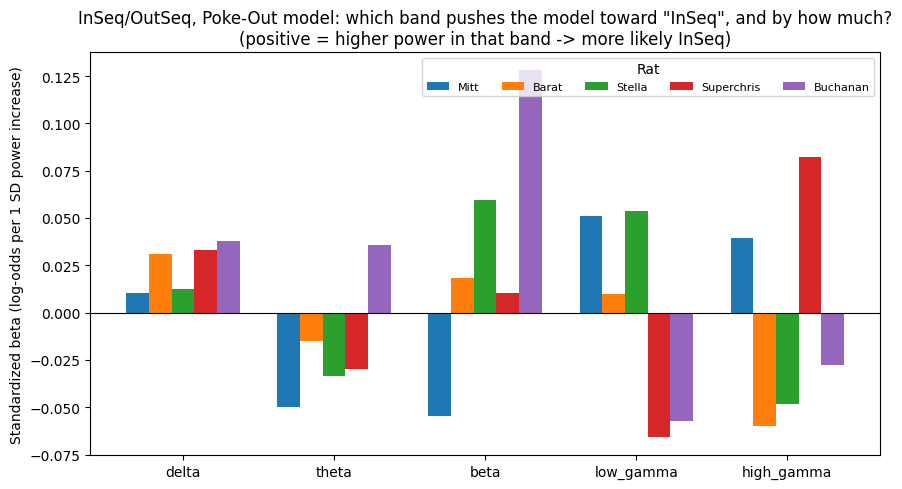

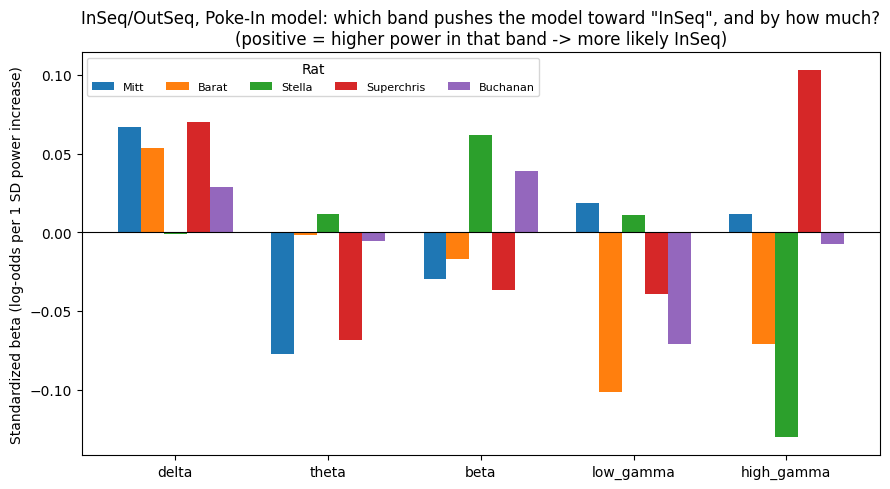

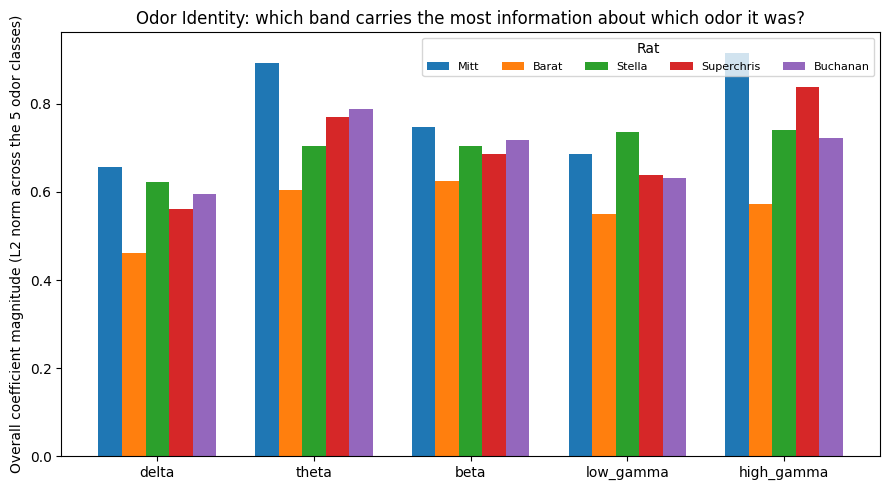

NOTE: run this notebook against the real data to fill in the specific 'which band wins, and for which rats' language in Section 9 below -- these bar charts are the source of truth for that claim, not a number typed in by hand.


In [35]:
def fit_final_and_get_band_betas(sess, window_cfg, task, band_names, n_channels_expected=None):
    """Refit the exact same pipeline used for evaluation on the FULL dataset (no CV split -- this is
    purely for reading out coefficients, not for reporting performance), then average |beta| across
    channels within each band. For the 2-class task this is one beta per feature; for the 5-class task
    LogisticRegression fits one coefficient vector per class (one-vs-rest under the hood), so we take
    the L2 norm across classes first to get a single 'how much does this feature matter overall' value
    per feature before averaging across channels."""
    X, y = get_features_for_window(sess, window_cfg, task=task)
    pipe = make_pipeline()
    pipe.fit(X, y)
    coefs = pipe.named_steps['clf'].coef_  # shape (1, n_features) binary, or (n_classes, n_features) multiclass
    if coefs.shape[0] == 1:
        feature_importance = coefs[0]
        signed = coefs[0]
    else:
        feature_importance = np.linalg.norm(coefs, axis=0)
        signed = None  # sign isn't single-valued in the multiclass case; handled per-class below

    n_bands = len(band_names)
    n_channels = X.shape[1] // n_bands
    importance_by_band = feature_importance.reshape(n_channels, n_bands).mean(axis=0)
    signed_by_band = signed.reshape(n_channels, n_bands).mean(axis=0) if signed is not None else None
    return importance_by_band, signed_by_band, coefs


def plot_inseq_betas_by_rat(betas_by_rat, title, filename):
    """Shared plotting code for the InSeq/OutSeq signed-beta bar charts, so the Poke-In and Poke-Out
    versions below are guaranteed to look identical apart from which betas they're fed."""
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(band_names))
    width = 0.15
    for i, (name, betas) in enumerate(betas_by_rat.items()):
        ax.bar(x + (i - 2) * width, betas, width, label=RAT_LABELS[name])
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(band_names)
    ax.set_ylabel('Standardized beta (log-odds per 1 SD power increase)')
    ax.set_title(title)
    ax.legend(title='Rat', ncol=5, fontsize=8)
    plt.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()


band_names = list(BANDS.keys())
x = np.arange(len(band_names))
width = 0.15

# ---- InSeq/OutSeq, Poke-Out model (INSEQ_WINDOW) -- one signed beta per band per rat ----
inseq_betas = {}
for sd in SESSION_DIRS:
    name = sd.name
    _, signed_by_band, _ = fit_final_and_get_band_betas(sessions[name], INSEQ_WINDOW, 'inseq', band_names)
    inseq_betas[name] = signed_by_band

plot_inseq_betas_by_rat(
    inseq_betas,
    'InSeq/OutSeq, Poke-Out model: which band pushes the model toward "InSeq", and by how much?\n'
    '(positive = higher power in that band -> more likely InSeq)',
    'inseq_pokeout_beta_by_band.png')


# ---- InSeq/OutSeq, Poke-In model (winning_pokein_config, Section 2a) -- same treatment, kept fully
# separate from the Poke-Out betas above since it's a different final model with its own window ----
pokein_inseq_betas = {}
for sd in SESSION_DIRS:
    name = sd.name
    _, signed_by_band, _ = fit_final_and_get_band_betas(sessions[name], winning_pokein_config, 'inseq', band_names)
    pokein_inseq_betas[name] = signed_by_band

plot_inseq_betas_by_rat(
    pokein_inseq_betas,
    'InSeq/OutSeq, Poke-In model: which band pushes the model toward "InSeq", and by how much?\n'
    '(positive = higher power in that band -> more likely InSeq)',
    'inseq_pokein_beta_by_band.png')


# ---- Odor Identity: overall |beta| per band per rat (5-class, so magnitude only) ----
odor_betas = {}
for sd in SESSION_DIRS:
    name = sd.name
    importance_by_band, _, _ = fit_final_and_get_band_betas(sessions[name], ODOR_WINDOW, 'odor', band_names)
    odor_betas[name] = importance_by_band

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, importances) in enumerate(odor_betas.items()):
    ax.bar(x + (i - 2) * width, importances, width, label=RAT_LABELS[name])
ax.set_xticks(x); ax.set_xticklabels(band_names)
ax.set_ylabel('Overall coefficient magnitude (L2 norm across the 5 odor classes)')
ax.set_title('Odor Identity: which band carries the most information about which odor it was?')
ax.legend(title='Rat', ncol=5, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'odor_beta_by_band.png', dpi=150, bbox_inches='tight')
plt.show()

print("NOTE: run this notebook against the real data to fill in the specific 'which band wins, and "
      "for which rats' language in Section 9 below -- these bar charts are the source of truth for "
      "that claim, not a number typed in by hand.")


### 6a. A clearer view of the same result: rat x band heatmap

The grouped bar charts above show the same numbers as this heatmap, just harder to scan -- five
clusters of five bars each asks the eye to compare bar heights across two dimensions at once. A
heatmap puts rat and band on the two axes and lets color do the comparison instead, which makes it
much faster to spot "is there one band that's dark (large effect) for every rat" -- the pattern that
would count as a reliable, general finding rather than a one-rat fluke. Three panels below, one per
model (InSeq/OutSeq Poke-In, InSeq/OutSeq Poke-Out, Odor Identity).



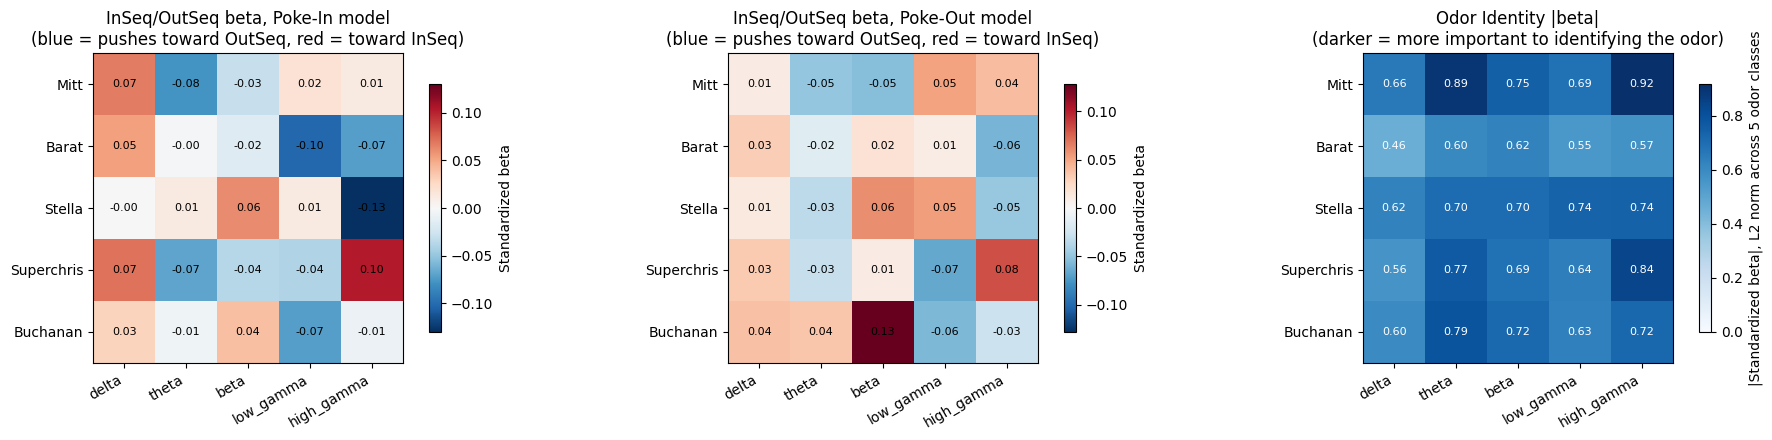

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

rat_names = [RAT_LABELS[sd.name] for sd in SESSION_DIRS]

pokein_inseq_matrix = np.array([pokein_inseq_betas[sd.name] for sd in SESSION_DIRS])  # (n_rats, n_bands), signed
im0 = axes[0].imshow(pokein_inseq_matrix, cmap='RdBu_r',
                      vmin=-np.abs(pokein_inseq_matrix).max(), vmax=np.abs(pokein_inseq_matrix).max())
axes[0].set_xticks(range(len(band_names))); axes[0].set_xticklabels(band_names, rotation=30, ha='right')
axes[0].set_yticks(range(len(rat_names))); axes[0].set_yticklabels(rat_names)
axes[0].set_title('InSeq/OutSeq beta, Poke-In model\n(blue = pushes toward OutSeq, red = toward InSeq)')
for r in range(pokein_inseq_matrix.shape[0]):
    for c in range(pokein_inseq_matrix.shape[1]):
        axes[0].text(c, r, f'{pokein_inseq_matrix[r, c]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im0, ax=axes[0], shrink=0.8, label='Standardized beta')

inseq_matrix = np.array([inseq_betas[sd.name] for sd in SESSION_DIRS])  # (n_rats, n_bands), signed
im1 = axes[1].imshow(inseq_matrix, cmap='RdBu_r', vmin=-np.abs(inseq_matrix).max(), vmax=np.abs(inseq_matrix).max())
axes[1].set_xticks(range(len(band_names))); axes[1].set_xticklabels(band_names, rotation=30, ha='right')
axes[1].set_yticks(range(len(rat_names))); axes[1].set_yticklabels(rat_names)
axes[1].set_title('InSeq/OutSeq beta, Poke-Out model\n(blue = pushes toward OutSeq, red = toward InSeq)')
for r in range(inseq_matrix.shape[0]):
    for c in range(inseq_matrix.shape[1]):
        axes[1].text(c, r, f'{inseq_matrix[r, c]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im1, ax=axes[1], shrink=0.8, label='Standardized beta')

odor_matrix = np.array([odor_betas[sd.name] for sd in SESSION_DIRS])  # (n_rats, n_bands), magnitude only
im2 = axes[2].imshow(odor_matrix, cmap='Blues', vmin=0)
axes[2].set_xticks(range(len(band_names))); axes[2].set_xticklabels(band_names, rotation=30, ha='right')
axes[2].set_yticks(range(len(rat_names))); axes[2].set_yticklabels(rat_names)
axes[2].set_title('Odor Identity |beta|\n(darker = more important to identifying the odor)')
for r in range(odor_matrix.shape[0]):
    for c in range(odor_matrix.shape[1]):
        axes[2].text(c, r, f'{odor_matrix[r, c]:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if odor_matrix[r, c] > odor_matrix.max() / 2 else 'black')
fig.colorbar(im2, ax=axes[2], shrink=0.8, label='|Standardized beta|, L2 norm across 5 odor classes')

plt.tight_layout()
plt.savefig(FIG_DIR / 'beta_by_band_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading these two charts.** The InSeq/OutSeq chart's y-axis crosses zero, so a bar's *side* of the
line (not just its height) is part of the finding -- a band with a tall bar above zero for every rat is
a genuinely reliable "more of this power -> more likely InSeq" signal, while a band that flips sign
between rats is not something to build a scientific claim on, even if it's large for one or two of
them. The Odor Identity chart cannot show sign this way (there is no single "more odor-identity-like"
direction across 5 unordered classes), so it only speaks to *how much* each band matters, not which way.

**Two follow-ups worth doing if there's time before the meeting, not required for the story above:**
(1) redo the Odor Identity version per-class (does theta separate odor A from B the same way it
separates C from D, or is it doing different work for different odor pairs?), and (2) tie the EDA
observation in Section 3b (theta power visibly differs InSeq vs. OutSeq in the raw band-power bars) to
the sign of the InSeq/OutSeq beta above -- if they agree, that's a nice independent check that the GLM
coefficient is picking up a real, visible effect and not an artifact of the fitting procedure.


### 6b. The direct answer: which band matters most, overall?

The bar charts and heatmap above show every rat's beta for every band -- accurate, but they make you
do the work of scanning across five bars or five cells to figure out which one actually wins. This
chart does that scanning for you: it collapses each band down to **one number** -- the average
importance across all 5 rats -- sorts the bands from most to least important, and marks the winner
explicitly. Variability across rats (as error bars) is shown alongside the average, so "most important"
also comes with a sense of how consistent that ranking is animal-to-animal. One ranking chart per
model below -- InSeq/OutSeq Poke-In, InSeq/OutSeq Poke-Out, and Odor Identity -- since there's no
reason the same band has to win all three.

For InSeq/OutSeq, "importance" here is |beta| (magnitude, direction stripped out, since a band that
reliably pushes hard in *either* direction is still a band the model is leaning on) -- the earlier
signed charts are still the place to check *which* direction. For Odor Identity there's no direction to
strip out; it's already a magnitude.


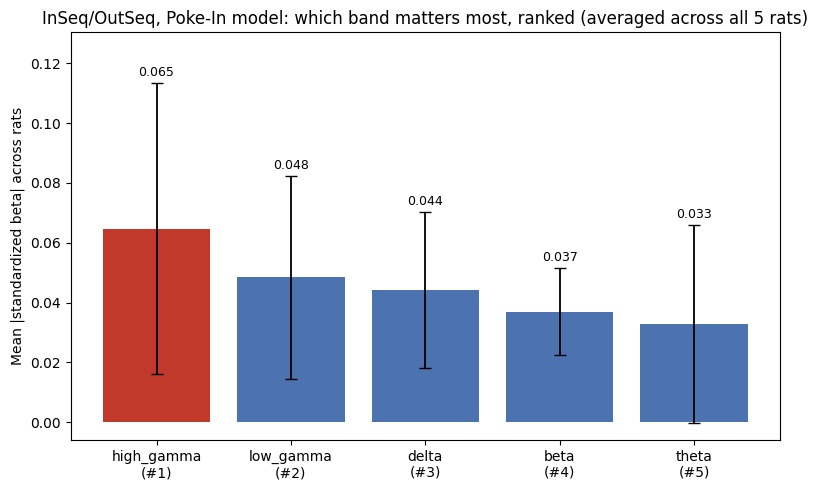

InSeq/OutSeq, Poke-In model ranking, most to least important: ['high_gamma', 'low_gamma', 'delta', 'beta', 'theta']


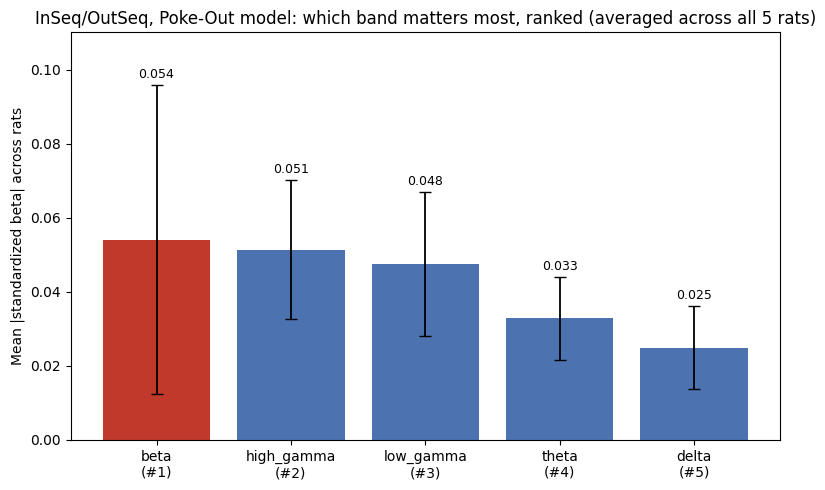

InSeq/OutSeq, Poke-Out model ranking, most to least important: ['beta', 'high_gamma', 'low_gamma', 'theta', 'delta']


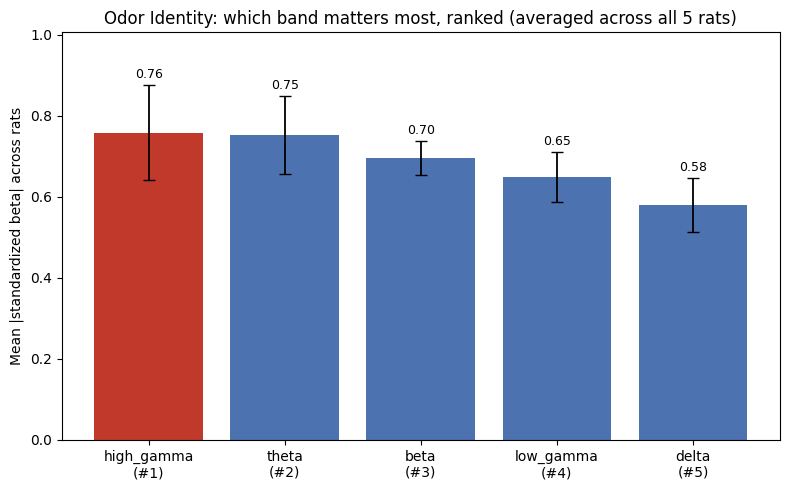

Odor Identity ranking, most to least important: ['high_gamma', 'theta', 'beta', 'low_gamma', 'delta']


In [48]:
def plot_band_ranking(betas_by_rat, title, ylabel, signed_input, fmt='%.2f'):
    matrix = np.array(list(betas_by_rat.values()))
    if signed_input:
        matrix = np.abs(matrix)
    means = matrix.mean(axis=0)
    stds = matrix.std(axis=0)
    order = np.argsort(means)[::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#C0392B' if i == 0 else '#4C72B0' for i in range(len(order))]
    bars = ax.bar(range(len(order)), means[order], yerr=stds[order], capsize=4, color=colors,
                  error_kw={'elinewidth': 1.3})
    
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=9)
    
    max_height = max(means[order] + stds[order])
    ax.set_ylim(top=max_height * 1.15)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f'{band_names[i]}\n(#{rank+1})' for rank, i in enumerate(order)])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    return fig, order

fig, pokein_inseq_order = plot_band_ranking(
    pokein_inseq_betas, 'InSeq/OutSeq, Poke-In model: which band matters most, ranked (averaged across all 5 rats)',
    'Mean |standardized beta| across rats', signed_input=True, fmt='%.3f')
fig.savefig(FIG_DIR / 'inseq_pokein_band_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('InSeq/OutSeq, Poke-In model ranking, most to least important:', [band_names[i] for i in pokein_inseq_order])

fig, inseq_order = plot_band_ranking(
    inseq_betas, 'InSeq/OutSeq, Poke-Out model: which band matters most, ranked (averaged across all 5 rats)',
    'Mean |standardized beta| across rats', signed_input=True, fmt='%.3f')
fig.savefig(FIG_DIR / 'inseq_pokeout_band_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('InSeq/OutSeq, Poke-Out model ranking, most to least important:', [band_names[i] for i in inseq_order])

fig, odor_order = plot_band_ranking(
    odor_betas, 'Odor Identity: which band matters most, ranked (averaged across all 5 rats)',
    'Mean |standardized beta| across rats', signed_input=False, fmt='%.2f')
fig.savefig(FIG_DIR / 'odor_band_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Odor Identity ranking, most to least important:', [band_names[i] for i in odor_order])

**This is the chart to put on a slide when someone asks "so which brain wave matters most?"** -- bands
are sorted left to right from most to least important (rank labeled under each bar), and the top band
is colored red so it reads at a glance without needing an extra label. The black error bars are +/-1
standard deviation of that band's |beta| across the 5 rats: short bars mean every rat agrees on how
much that band matters; long bars mean it's more rat-dependent, which is worth mentioning out loud if
the #1 band's bar is long -- it means the ranking is real on average but not equally strong in every
animal.


## 6c. Which Band Matters, *and When*? A Time-Resolved View

Section 6 answers "which band matters" using one fixed window per task -- a single number per band,
summarizing the whole 500-1500ms slice at once. That collapses away any information about *when inside
the window* a band's power actually becomes informative. This section asks the sharper question: **if
we slide a short sub-window across time and refit the model at each position, does the same band stay
important throughout, or does the important band change as the trial unfolds?**

**How this works, concretely:** instead of one window per task, we use many short, overlapping
sub-windows (250ms wide, stepped every 125ms) spanning a broader stretch of time around the same
reference event as the Section 2b/2d final windows (Poke-Out for InSeq/OutSeq, Poke-In for Odor Identity).
At each sub-window position, we extract band power exactly as before and refit the same GLM
(`StandardScaler` + `LogisticRegression`) on that slice alone, then read off the same per-band beta
used in Section 6. Stacking these betas by sub-window position gives a **time x band heatmap**: one
row per band, one column per time point, color = how much (and, for InSeq/OutSeq, which direction) that
band mattered *at that specific moment*.

**One explicit methodological note:** this exploratory sliding search deliberately looks both *before
and after* the reference event, on purpose -- the goal here is descriptive (mapping out where in time
each band's information lives), not a final predictive claim. This is different from Section 4's
concern about the InSeq/OutSeq training window leaking information from after Poke-Out -- that concern
is about what a *final, reported* model is allowed to use; it doesn't apply to an exploratory map like
this one, whose whole purpose is to show what happens on both sides of the event.


In [38]:
def band_importance_over_time(sess, reference, time_starts_ms, window_len_ms, task, band_names,
                               min_trials=15):
    """Refit the same GLM used in Section 6 at each of many sliding sub-window positions, and
    collect per-band betas over time. Returns (n_bands, n_timepoints) -- signed for the binary task,
    magnitude (L2 norm across classes) for the multiclass task -- plus the list of window centers
    actually used (a window is skipped, and filled with NaN, if too few trials survive it)."""
    n_bands = len(band_names)
    betas_over_time = np.full((n_bands, len(time_starts_ms)), np.nan)
    for i, start_ms in enumerate(time_starts_ms):
        window_cfg = {'name': f'{reference}_{start_ms}_{window_len_ms}', 'reference': reference,
                      'offset_ms': int(start_ms), 'length_ms': window_len_ms}
        try:
            X, y = get_features_for_window(sess, window_cfg, task=task)
        except ValueError:
            continue
        if len(y) < min_trials or len(np.unique(y)) < 2:
            continue
        pipe = make_pipeline()
        pipe.fit(X, y)
        coefs = pipe.named_steps['clf'].coef_
        n_channels = X.shape[1] // n_bands
        if coefs.shape[0] == 1:
            importance = coefs[0]
        else:
            importance = np.linalg.norm(coefs, axis=0)
        betas_over_time[:, i] = importance.reshape(n_channels, n_bands).mean(axis=0)
    return betas_over_time


# InSeq/OutSeq: slide from 1000ms before Poke-Out to 750ms after it (covers the original window and
# then some, on both sides, purely for this exploratory map -- see the note above)
INSEQ_TIME_STARTS = list(range(-1000, 751, 125))
INSEQ_SUBWINDOW_MS = 250

# Odor Identity: slide across the original 0-1500ms Poke-In window
ODOR_TIME_STARTS = list(range(0, 1251, 125))
ODOR_SUBWINDOW_MS = 250

inseq_time_betas = {}   # name -> (n_bands, n_timepoints), signed
odor_time_betas = {}    # name -> (n_bands, n_timepoints), magnitude

for sd in SESSION_DIRS:
    name = sd.name
    print(f"Sliding-window importance: {RAT_LABELS[name]}...")
    inseq_time_betas[name] = band_importance_over_time(
        sessions[name], 'pokeout', INSEQ_TIME_STARTS, INSEQ_SUBWINDOW_MS, 'inseq', band_names)
    odor_time_betas[name] = band_importance_over_time(
        sessions[name], 'pokein', ODOR_TIME_STARTS, ODOR_SUBWINDOW_MS, 'odor', band_names)

print("Done.")


Sliding-window importance: Mitt...
Sliding-window importance: Barat...
Sliding-window importance: Stella...
Sliding-window importance: Superchris...
Sliding-window importance: Buchanan...
Done.


### 6d. Reading the time x band heatmaps below

Each heatmap has **time along the x-axis** (relative to the reference event, marked with a vertical
line at 0) and **frequency band along the y-axis**. For InSeq/OutSeq, color follows the same red/blue
convention as Section 6a (red = pushes toward InSeq, blue = toward OutSeq, white = no effect at
that moment); for Odor Identity, color is magnitude only (darker = more informative about odor
identity at that moment, no direction). The shaded vertical band marks each task's original,
final-model training window from Section 2, so it's easy to see whether the window we've been
reporting results for actually sits on top of the moment(s) that matter most, or whether the signal is
concentrated somewhere else in time. **This is exactly the kind of figure to use for drawing a
conclusion like "band X only matters in the Yms right before/after the event, not throughout the whole
window."**


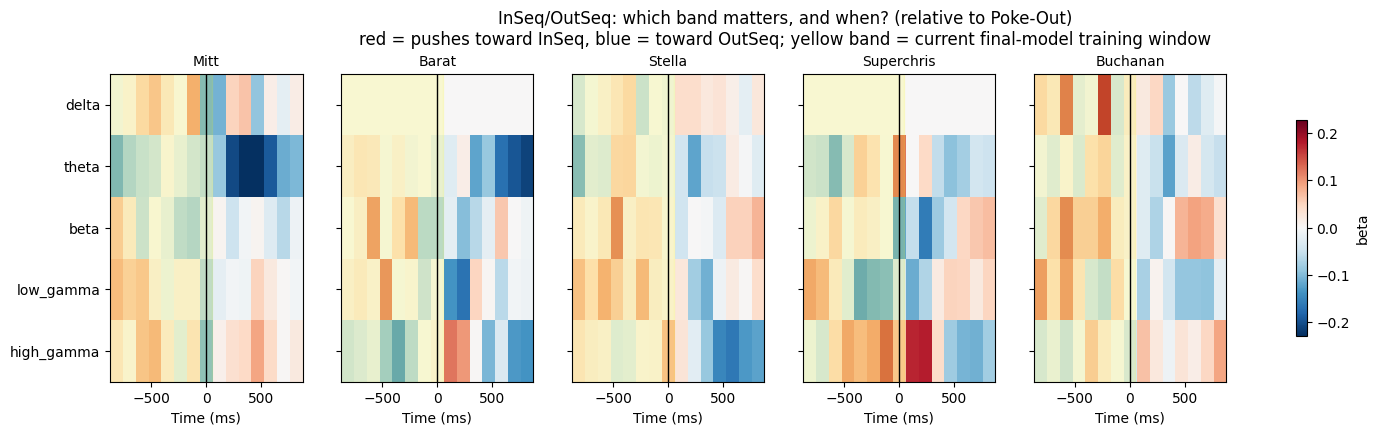

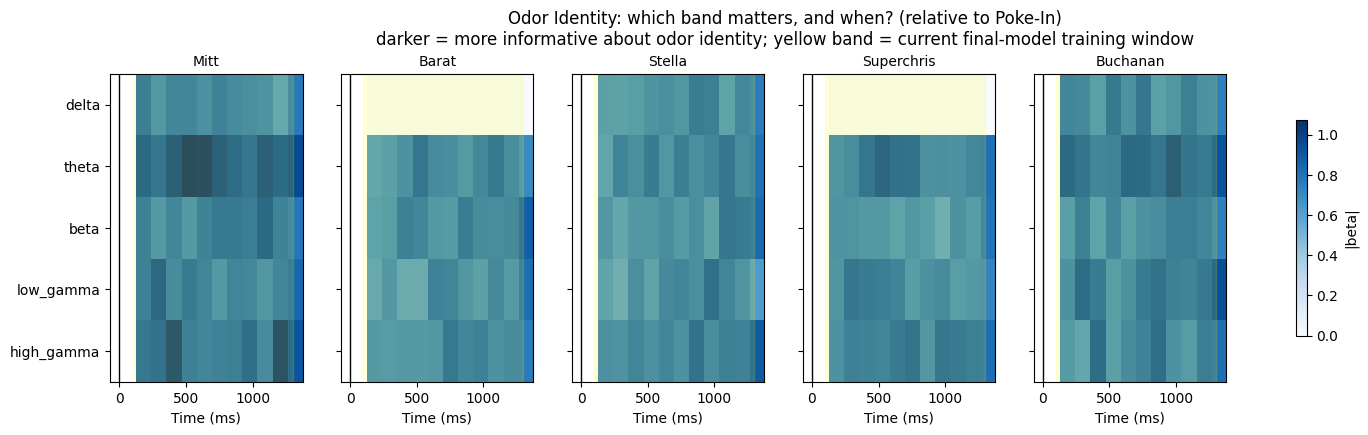

In [39]:
def plot_time_band_heatmap(betas_by_rat, time_starts, subwindow_ms, band_names, title, cmap,
                            symmetric, highlight_window):
    n_rats = len(betas_by_rat)
    fig, axes = plt.subplots(1, n_rats, figsize=(3.6 * n_rats, 4), sharey=True)
    time_centers = np.array(time_starts) + subwindow_ms / 2
    vmax = np.nanmax([np.nanmax(np.abs(b)) for b in betas_by_rat.values()])
    for ax, (name, betas) in zip(np.atleast_1d(axes), betas_by_rat.items()):
        if symmetric:
            im = ax.imshow(betas, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax,
                            extent=[time_centers[0], time_centers[-1], len(band_names) - 0.5, -0.5])
        else:
            im = ax.imshow(betas, aspect='auto', cmap=cmap, vmin=0, vmax=vmax,
                            extent=[time_centers[0], time_centers[-1], len(band_names) - 0.5, -0.5])
        ax.axvline(0, color='black', lw=1)
        ax.axvspan(highlight_window[0], highlight_window[1], color='yellow', alpha=0.15)
        ax.set_yticks(range(len(band_names))); ax.set_yticklabels(band_names)
        ax.set_title(RAT_LABELS[name], fontsize=10)
        ax.set_xlabel('Time (ms)')
    fig.colorbar(im, ax=axes, shrink=0.7, label='beta' if symmetric else '|beta|')
    fig.suptitle(title, y=1.04)
    return fig


fig1 = plot_time_band_heatmap(
    inseq_time_betas, INSEQ_TIME_STARTS, INSEQ_SUBWINDOW_MS, band_names,
    'InSeq/OutSeq: which band matters, and when? (relative to Poke-Out)\n'
    'red = pushes toward InSeq, blue = toward OutSeq; yellow band = current final-model training window',
    cmap='RdBu_r', symmetric=True,
    highlight_window=(INSEQ_WINDOW['offset_ms'], INSEQ_WINDOW['offset_ms'] + INSEQ_WINDOW['length_ms']),
)
fig1.savefig(FIG_DIR / 'inseq_beta_time_band_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = plot_time_band_heatmap(
    odor_time_betas, ODOR_TIME_STARTS, ODOR_SUBWINDOW_MS, band_names,
    'Odor Identity: which band matters, and when? (relative to Poke-In)\n'
    'darker = more informative about odor identity; yellow band = current final-model training window',
    cmap='Blues', symmetric=False,
    highlight_window=(ODOR_WINDOW['offset_ms'], ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms']),
)
fig2.savefig(FIG_DIR / 'odor_beta_time_band_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**What to actually look for once this has run on real data:** (1) a band whose color is strong and
consistent in the same direction across a wide time range means "this band matters broadly, not at one
instant" -- a durable representation; (2) a band that's only dark right around t=0 and fades quickly on
either side is telling a much more specific story -- its information is tied tightly to the event
itself, not a slow drift; (3) comparing where the strongest color sits to the yellow highlighted band
(today's official training window) tells you directly whether the reported InSeq/OutSeq and Odor
Identity numbers are actually being driven by the time period we're claiming, or whether a shifted
window would do just as well or better -- which is exactly the question Section 2's sliding-window searches were built to answer directly.


### 6e. All Three Models Side by Side: Which Band Wins, Overall?

Sections 6a-6d each look at one model at a time. This section puts the InSeq/OutSeq Poke-In model,
the InSeq/OutSeq Poke-Out model, and the Odor Identity model on the same chart, so "which frequency
band actually matters" gets one answer across all three windows tested in this notebook, not three
separate ones.

Section 6 above only fit betas for the Poke-Out InSeq/OutSeq model (the one used for interpretability
everywhere else in this notebook, per Section 2's rationale) and the Odor Identity model. The Poke-In
InSeq/OutSeq model's betas are fit fresh in the next cell, the same way (a single fit on the full
dataset, no CV, purely to read out coefficients) using the confirmed winning window from Section 2a --
hardcoded below so this section does not depend on re-running the sliding-window searches above.

Because the 2-class and 5-class tasks produce beta magnitudes on very different scales, each model's
five bands are converted to a percentage of that model's own total |beta| before plotting. That keeps
the comparison about *relative* importance within each model, not raw coefficient size. The beta
band's bars are outlined in black across all three groups so it is easy to track.


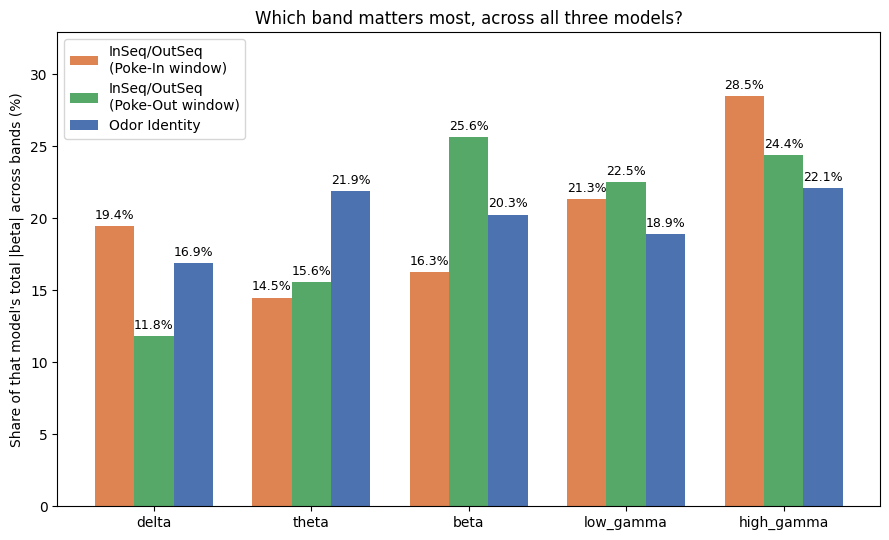

InSeq/OutSeq (Poke-In window): high_gamma (28.5%), low_gamma (21.3%), delta (19.4%), beta (16.3%), theta (14.5%)
InSeq/OutSeq (Poke-Out window): beta (25.6%), high_gamma (24.4%), low_gamma (22.5%), theta (15.6%), delta (11.8%)
Odor Identity: high_gamma (22.1%), theta (21.9%), beta (20.3%), low_gamma (18.9%), delta (16.9%)


In [46]:
# These used to be hardcoded here as a fixed copy of "confirmed winning windows" (rather than reusing
# winning_pokein_config / INSEQ_WINDOW / ODOR_WINDOW), so this section could be re-run without needing
# the sliding-window searches above to execute first. That copy had drifted out of sync with the actual
# search winners and with the Section 2 constraints -- the old POKEIN_INSEQ_WINDOW ran 350-1850ms,
# well past a typical Poke-Out -- which is exactly the bug this notebook fixes. Reading the live
# winners from Section 2 instead means this can't silently drift again; if you need to re-run just this
# section standalone, re-paste the printed dict literals from Section 2's output back in here.
POKEIN_INSEQ_WINDOW = winning_pokein_config
POKEOUT_INSEQ_WINDOW = INSEQ_WINDOW
ODOR_ID_WINDOW = ODOR_WINDOW

# Only the Poke-In InSeq/OutSeq betas are new -- inseq_betas (Poke-Out) and odor_betas already exist
# from Section 6.
pokein_betas = {}
for sd in SESSION_DIRS:
    name = sd.name
    _, signed_by_band, _ = fit_final_and_get_band_betas(sessions[name], POKEIN_INSEQ_WINDOW, 'inseq', band_names)
    pokein_betas[name] = signed_by_band


def band_importance_share(betas_by_rat, signed_input):
    """Mean |beta| per band across rats, expressed as a % of that model's own total -- puts models
    with very different beta scales on the same axis."""
    matrix = np.array(list(betas_by_rat.values()))
    if signed_input:
        matrix = np.abs(matrix)
    mean_by_band = matrix.mean(axis=0)
    return mean_by_band / mean_by_band.sum() * 100


model_shares = {
    'InSeq/OutSeq\n(Poke-In window)': band_importance_share(pokein_betas, signed_input=True),
    'InSeq/OutSeq\n(Poke-Out window)': band_importance_share(inseq_betas, signed_input=True),
    'Odor Identity': band_importance_share(odor_betas, signed_input=False),
}

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(band_names))
width = 0.25
colors = ['#DD8452', '#55A868', '#4C72B0']
beta_idx = band_names.index('beta')

for i, (model_name, shares) in enumerate(model_shares.items()):
    bars = ax.bar(x + (i - 1) * width, shares, width, label=model_name, color=colors[i])
    # Add values on top of each bar formatted as percentages
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

# Expand y-axis upper limit slightly so labels don't get cut off by the top border
ax.set_ylim(top=ax.get_ylim()[1] * 1.1)

ax.set_xticks(x)
ax.set_xticklabels(band_names)
ax.set_ylabel("Share of that model's total |beta| across bands (%)")
ax.set_title('Which band matters most, across all three models?')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'three_model_band_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

for model_name, shares in model_shares.items():
    order = np.argsort(shares)[::-1]
    ranked = ', '.join(f'{band_names[i]} ({shares[i]:.1f}%)' for i in order)
    print(f"{model_name.replace(chr(10), ' ')}: {ranked}")

### 6f. What Do These Windows Actually Look Like on the Raw Signal?

The bar charts above describe the model, not the data feeding it. This section plots one
representative trial's raw LFP trace and shades exactly which stretch of it each of the three
training windows uses, on a single timeline anchored to that trial's own Poke-In and Poke-Out times.
This is also a direct visual check on whether the Poke-In InSeq/OutSeq window bleeds into the
Poke-Out period: here it is the actual data, not just the millisecond math.


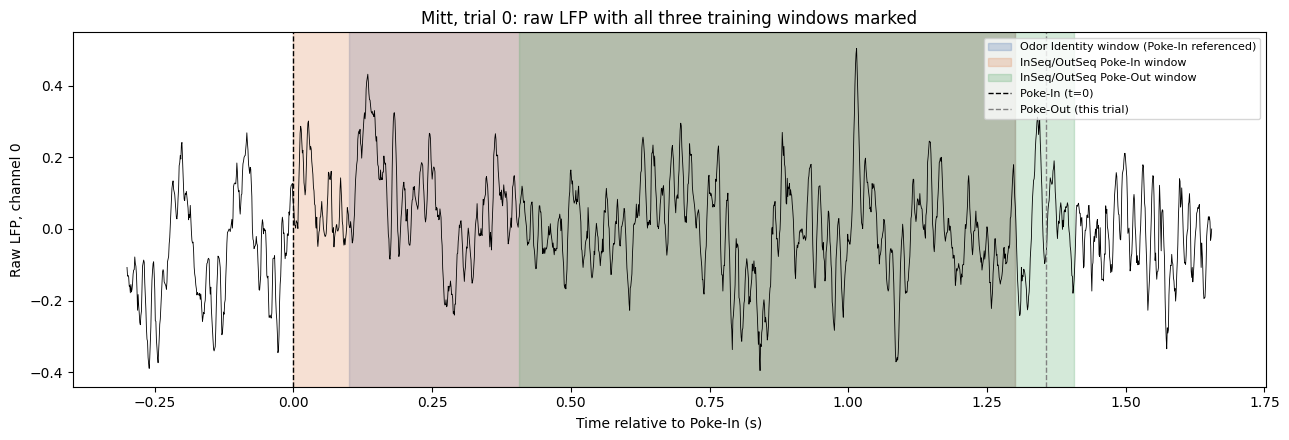

In [41]:
# One representative trial (first InSeq/OutSeq-eligible trial with a valid Poke-Out and enough
# surrounding data on both sides) from Mitt's session, purely to show what the raw signal looks like
# under each window -- not a formal result.
example_name = '080718_mitt'
example_sess = sessions[example_name]
timebin = example_sess['timebin']
trial_idx = example_sess['labels']['trial_idx']
pokeout_idx = example_sess['pokeout_idx']

chosen_trial = None
for i, (t_in, t_out) in enumerate(zip(trial_idx, pokeout_idx)):
    if t_out < 0:
        continue
    poke_in_time = timebin[t_in]
    poke_out_time = timebin[t_out]
    plot_start = poke_in_time - 0.3
    plot_end = poke_in_time + (POKEIN_INSEQ_WINDOW['offset_ms'] + POKEIN_INSEQ_WINDOW['length_ms']) / 1000
    if plot_start >= timebin[0] and plot_end <= timebin[-1] and poke_out_time > poke_in_time:
        chosen_trial = i
        break

t_in_idx = trial_idx[chosen_trial]
t_out_idx = pokeout_idx[chosen_trial]
poke_in_time = timebin[t_in_idx]
poke_out_time = timebin[t_out_idx]

plot_start = poke_in_time - 0.3
plot_end = max(poke_in_time + (POKEIN_INSEQ_WINDOW['offset_ms'] + POKEIN_INSEQ_WINDOW['length_ms']) / 1000,
               poke_out_time + 0.3)
start_idx = np.searchsorted(timebin, plot_start)
end_idx = np.searchsorted(timebin, plot_end)

trace = example_sess['lfp_data'][0, start_idx:end_idx]  # single channel, raw trace
t = timebin[start_idx:end_idx] - poke_in_time  # relative to Poke-In


def shade(ax, offset_ms, length_ms, ref_time, color, label):
    start = (ref_time - poke_in_time) + offset_ms / 1000
    end = start + length_ms / 1000
    ax.axvspan(start, end, color=color, alpha=0.25, label=label)


fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(t, trace, color='black', linewidth=0.6)
shade(ax, ODOR_ID_WINDOW['offset_ms'], ODOR_ID_WINDOW['length_ms'], poke_in_time, '#4C72B0', 'Odor Identity window (Poke-In referenced)')
shade(ax, POKEIN_INSEQ_WINDOW['offset_ms'], POKEIN_INSEQ_WINDOW['length_ms'], poke_in_time, '#DD8452', 'InSeq/OutSeq Poke-In window')
shade(ax, POKEOUT_INSEQ_WINDOW['offset_ms'], POKEOUT_INSEQ_WINDOW['length_ms'], poke_out_time, '#55A868', 'InSeq/OutSeq Poke-Out window')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Poke-In (t=0)')
ax.axvline(poke_out_time - poke_in_time, color='gray', linestyle='--', linewidth=1, label='Poke-Out (this trial)')
ax.set_xlabel('Time relative to Poke-In (s)')
ax.set_ylabel('Raw LFP, channel 0')
ax.set_title(f"{RAT_LABELS[example_name]}, trial {chosen_trial}: raw LFP with all three training windows marked")
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_lfp_with_windows.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Summary Across Both Tasks

"InSeq/OutSeq" below refers to the Poke-Out model (Section 2b); the Poke-In model's numbers are in
Section 2a.


In [42]:
summary = pd.DataFrame({
    'InSeq/OutSeq bal.acc': {RAT_LABELS[n]: r['balanced_accuracy'] for n, r in inseq_final_results.items()},
    'InSeq/OutSeq AUC': {RAT_LABELS[n]: r['auc'] for n, r in inseq_final_results.items()},
    'InSeq/OutSeq p': {RAT_LABELS[n]: r['p_value'] for n, r in inseq_final_results.items()},
    'Odor ID bal.acc': {RAT_LABELS[n]: r['balanced_accuracy'] for n, r in odor_final_results.items()},
    'Odor ID AUC(ovr)': {RAT_LABELS[n]: r['auc'] for n, r in odor_final_results.items()},
    'Odor ID p': {RAT_LABELS[n]: r['p_value'] for n, r in odor_final_results.items()},
}).round(3)
summary


,InSeq/OutSeq bal.acc,InSeq/OutSeq AUC,InSeq/OutSeq p,Odor ID bal.acc,Odor ID AUC(ovr),Odor ID p
Mitt,0.687,0.775,0.01,0.519,0.808,0.01
Barat,0.736,0.859,0.01,0.477,0.777,0.01
Stella,0.709,0.797,0.01,0.503,0.809,0.01
Superchris,0.808,0.887,0.01,0.511,0.806,0.01
Buchanan,0.671,0.748,0.01,0.578,0.854,0.01


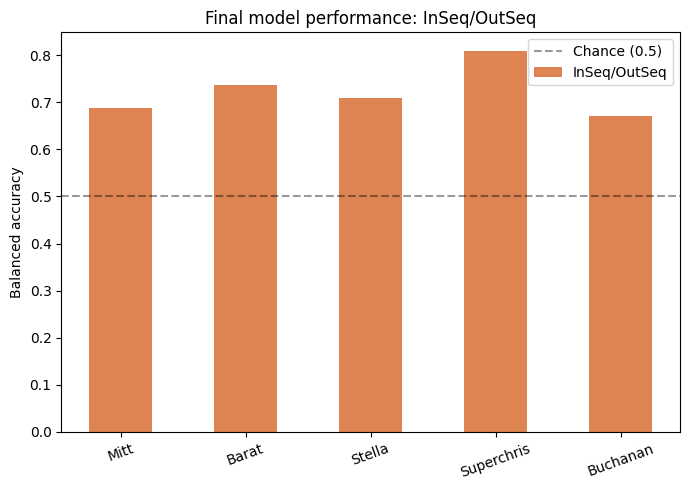

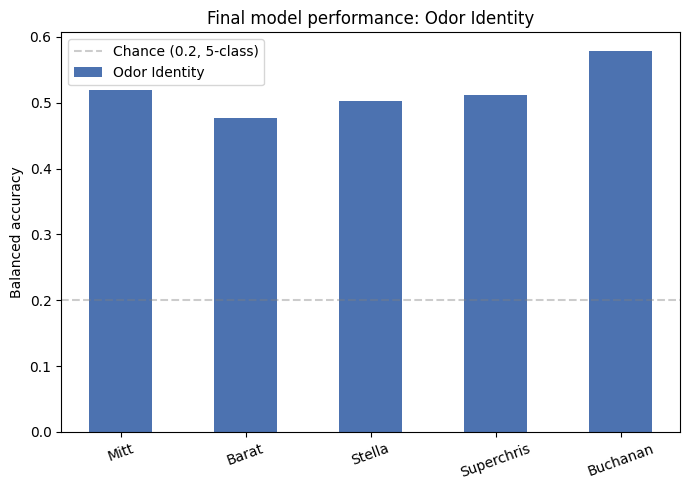

In [43]:
rats = summary.index.tolist()
x = np.arange(len(rats))
width = 0.5

# Graph 1: InSeq/OutSeq Task
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, summary['InSeq/OutSeq bal.acc'], width, color='#DD8452', label='InSeq/OutSeq')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.4, label='Chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(rats, rotation=20)
ax.set_ylabel('Balanced accuracy')
ax.set_title('Final model performance: InSeq/OutSeq')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'inseq_outseq_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Graph 2: Odor Identity Task
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, summary['Odor ID bal.acc'], width, color='#4C72B0', label='Odor Identity')
ax.axhline(0.2, color='gray', linestyle='--', alpha=0.4, label='Chance (0.2, 5-class)')
ax.set_xticks(x)
ax.set_xticklabels(rats, rotation=20)
ax.set_ylabel('Balanced accuracy')
ax.set_title('Final model performance: Odor Identity')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'odor_id_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Why show AUC separately from balanced accuracy:** balanced accuracy depends on where the model's
decision threshold happens to fall, while AUC summarizes performance across *all* thresholds -- useful
here because it's a fairer point of comparison against chance (0.5 for any binary or one-vs-rest AUC,
regardless of class imbalance), labeled explicitly on both panels below.


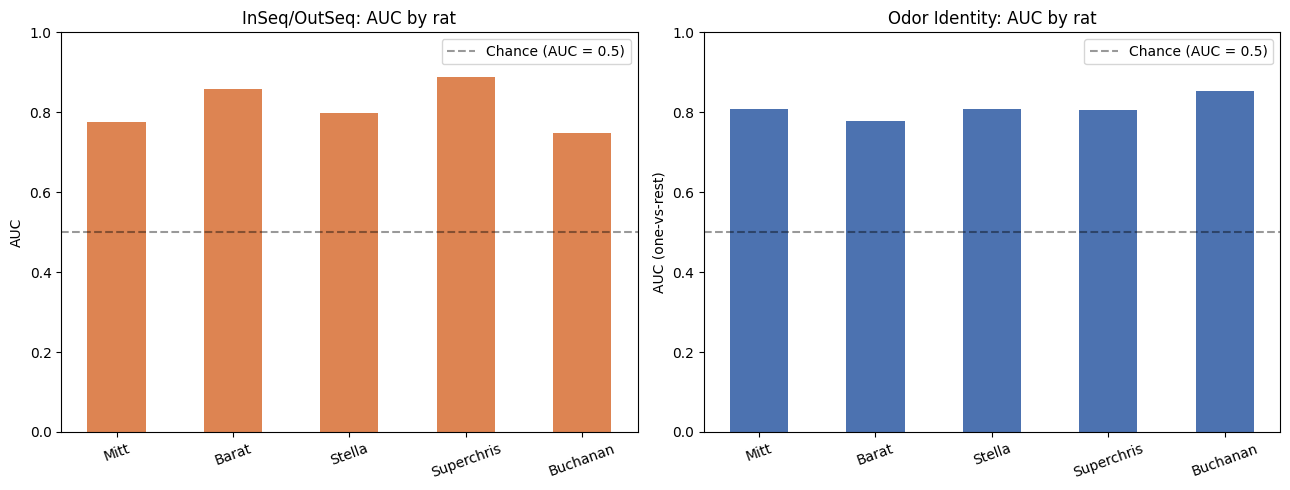

In [44]:
# Graph 3 & 4: AUC per rat, both tasks -- chance level explicitly labeled at 0.5
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x, summary['InSeq/OutSeq AUC'], width, color='#DD8452')
axes[0].axhline(0.5, color='black', linestyle='--', alpha=0.4, label='Chance (AUC = 0.5)')
axes[0].set_xticks(x); axes[0].set_xticklabels(rats, rotation=20)
axes[0].set_ylabel('AUC'); axes[0].set_ylim(0, 1)
axes[0].set_title('InSeq/OutSeq: AUC by rat')
axes[0].legend()

axes[1].bar(x, summary['Odor ID AUC(ovr)'], width, color='#4C72B0')
axes[1].axhline(0.5, color='black', linestyle='--', alpha=0.4, label='Chance (AUC = 0.5)')
axes[1].set_xticks(x); axes[1].set_xticklabels(rats, rotation=20)
axes[1].set_ylabel('AUC (one-vs-rest)'); axes[1].set_ylim(0, 1)
axes[1].set_title('Odor Identity: AUC by rat')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'auc_summary_both_tasks.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Export Results

In [45]:
def _nan_to_none(x):
    """Recursively swap NaN for None so the interpretability arrays below serialize as valid JSON
    (a sub-window with too few trials gets skipped and left as NaN in Section 6c -- see that section's
    band_importance_over_time docstring)."""
    if isinstance(x, float) and np.isnan(x):
        return None
    if isinstance(x, list):
        return [_nan_to_none(v) for v in x]
    return x

export = {
    'purpose': 'Final models notebook: InSeq/OutSeq Poke-In model, InSeq/OutSeq Poke-Out model (both from sliding-window searches), and Odor Identity, all 5 rats',
    'min_window_length_ms': MIN_WINDOW_LENGTH_MS,
    'screen_cv_repeats': SCREEN_CV_REPEATS,
    'inseq_pokein_window': winning_pokein_config,
    'inseq_pokeout_window': winning_prepokeout_config,
    'inseq_window': INSEQ_WINDOW,  # alias -- currently == inseq_pokeout_window, see Section 2c
    'odor_window': ODOR_WINDOW,
    'window_selection_stability_check': {
        label: [{'winner': n, 'score': None if s is None or np.isnan(s) else round(float(s), 4)} for n, s in runs]
        for label, runs in stability_results.items()
    },

    # --- Section 2a: InSeq/OutSeq, Poke-In model ---
    'inseq_pokein_results': {
        name: {
            'balanced_accuracy': round(r['balanced_accuracy'], 4),
            'auc': round(r['auc'], 4),
            'p_value': round(r['p_value'], 6),
            'confusion_matrix_percent': r['cm_pct'].round(1).tolist(),
            'confusion_matrix_counts': r['cm_counts'].astype(int).tolist(),
        } for name, r in pokein_inseq_results.items()
    },
    'inseq_pokein_combined_total_confusion_matrix': combined_pokein_inseq_counts.astype(int).tolist(),

    # --- Section 2b: InSeq/OutSeq, Poke-Out model -- this is also INSEQ_WINDOW / inseq_final_results,
    # i.e. the model used for interpretability (Section 6) and the headline "InSeq/OutSeq" result ---
    'inseq_results': {
        name: {
            'balanced_accuracy': round(r['balanced_accuracy'], 4),
            'auc': round(r['auc'], 4),
            'p_value': round(r['p_value'], 6),
            'confusion_matrix_percent': r['cm_pct'].round(1).tolist(),
            'confusion_matrix_counts': r['cm_counts'].astype(int).tolist(),
        } for name, r in inseq_final_results.items()
    },
    'inseq_combined_total_confusion_matrix': combined_prepokeout_counts.astype(int).tolist(),

    # --- Section 5: Odor Identity ---
    'odor_results': {
        name: {
            'balanced_accuracy': round(r['balanced_accuracy'], 4),
            'auc_ovr': round(r['auc'], 4),
            'p_value': round(r['p_value'], 6),
            'confusion_matrix_percent': r['cm_pct'].round(1).tolist(),
            'confusion_matrix_counts': r['cm_counts'].astype(int).tolist(),
        } for name, r in odor_final_results.items()
    },
    'odor_combined_total_confusion_matrix': combined_odor_counts.astype(int).tolist(),

    # --- Interpretability (Section 6): one beta per band, whole-window GLM, per rat. inseq betas are
    # for the Poke-Out model (INSEQ_WINDOW), since that's what Section 6 interprets. ---
    'band_names': band_names,
    'pokein_inseq_beta_by_band': {
        # signed: positive = pushes toward InSeq, negative = toward OutSeq -- Poke-In model (Section 2a)
        name: [round(float(b), 4) for b in betas] for name, betas in pokein_inseq_betas.items()
    },
    'inseq_beta_by_band': {
        # signed: positive = pushes toward InSeq, negative = toward OutSeq -- Poke-Out model (Section 2b,
        # == INSEQ_WINDOW, the one Section 6's discussion focuses on)
        name: [round(float(b), 4) for b in betas] for name, betas in inseq_betas.items()
    },
    'odor_beta_by_band': {
        # magnitude only (L2 norm across the 5 odor classes) -- no single "direction" for 5 classes
        name: [round(float(b), 4) for b in betas] for name, betas in odor_betas.items()
    },

    # --- Interpretability (Section 6b): overall ranking, averaged across all 5 rats ---
    'pokein_inseq_band_ranking': {
        'order_most_to_least_important': [band_names[i] for i in pokein_inseq_order],
        'mean_abs_beta': {band_names[i]: round(float(np.abs(np.array(list(pokein_inseq_betas.values())))[:, i].mean()), 4)
                           for i in range(len(band_names))},
        'std_abs_beta_across_rats': {band_names[i]: round(float(np.abs(np.array(list(pokein_inseq_betas.values())))[:, i].std()), 4)
                                      for i in range(len(band_names))},
    },
    'inseq_band_ranking': {
        'order_most_to_least_important': [band_names[i] for i in inseq_order],
        'mean_abs_beta': {band_names[i]: round(float(np.abs(np.array(list(inseq_betas.values())))[:, i].mean()), 4)
                           for i in range(len(band_names))},
        'std_abs_beta_across_rats': {band_names[i]: round(float(np.abs(np.array(list(inseq_betas.values())))[:, i].std()), 4)
                                      for i in range(len(band_names))},
    },
    'odor_band_ranking': {
        'order_most_to_least_important': [band_names[i] for i in odor_order],
        'mean_abs_beta': {band_names[i]: round(float(np.array(list(odor_betas.values()))[:, i].mean()), 4)
                           for i in range(len(band_names))},
        'std_abs_beta_across_rats': {band_names[i]: round(float(np.array(list(odor_betas.values()))[:, i].std()), 4)
                                      for i in range(len(band_names))},
    },

    # --- Interpretability (Section 6c): time-resolved beta, one value per band per time-bin per rat ---
    # inseq: signed (direction meaningful); odor: magnitude only. Time values are bin-start ms,
    # relative to Poke-Out (inseq) or Poke-In (odor). A null entry means that sub-window had too few
    # trials and was skipped (see band_importance_over_time in Section 6c).
    'inseq_time_resolved_beta': {
        'time_starts_ms': INSEQ_TIME_STARTS,
        'subwindow_length_ms': INSEQ_SUBWINDOW_MS,
        'beta_by_rat_and_band': {
            name: {band_names[b]: _nan_to_none(arr[b, :].round(4).tolist()) for b in range(len(band_names))}
            for name, arr in inseq_time_betas.items()
        },
    },
    'odor_time_resolved_beta': {
        'time_starts_ms': ODOR_TIME_STARTS,
        'subwindow_length_ms': ODOR_SUBWINDOW_MS,
        'beta_by_rat_and_band': {
            name: {band_names[b]: _nan_to_none(arr[b, :].round(4).tolist()) for b in range(len(band_names))}
            for name, arr in odor_time_betas.items()
        },
    },
}

with open(LOG_DIR / 'notebook024c_final_models_results.json', 'w') as f:
    _json.dump(export, f, indent=2)

print("Saved to outputs/logs/notebook024c_final_models_results.json")
print(_json.dumps(export, indent=2)[:2000], "...")

Saved to outputs/logs/notebook024c_final_models_results.json
{
  "purpose": "Final models notebook: InSeq/OutSeq Poke-In model, InSeq/OutSeq Poke-Out model (both from sliding-window searches), and Odor Identity, all 5 rats",
  "min_window_length_ms": 1000,
  "screen_cv_repeats": 3,
  "inseq_pokein_window": {
    "name": "pokein_0_1300",
    "reference": "pokein",
    "offset_ms": 0,
    "length_ms": 1300
  },
  "inseq_pokeout_window": {
    "name": "prepokeout_end50_len1000",
    "reference": "pokeout",
    "offset_ms": -950,
    "length_ms": 1000
  },
  "inseq_window": {
    "name": "prepokeout_end50_len1000",
    "reference": "pokeout",
    "offset_ms": -950,
    "length_ms": 1000
  },
  "odor_window": {
    "name": "odor_pokein_100_1200",
    "reference": "pokein",
    "offset_ms": 100,
    "length_ms": 1200
  },
  "window_selection_stability_check": {},
  "inseq_pokein_results": {
    "080718_mitt": {
      "balanced_accuracy": 0.6793,
      "auc": 0.7365,
      "p_value": 0.01,
  

## 9. Written Summary

**Objective.** Produce the final, presentation-ready models for both classification tasks
(InSeq/OutSeq and Odor Identity), using windows chosen by dedicated sliding-window searches (Section 2)
rather than one window assumed to fit every reference event or every task, across all 5 rats, with
supporting EDA, raw-data visualizations, and a dedicated interpretability analysis of which frequency
band each model relies on.

**Data.** Four hippocampal LFP channels plus behavioral event markers (Poke-In, Poke-Out, odor
identity) per rat, for 5 rats (Mitt, Barat, Stella, Superchris, Buchanan). Each trial contributes one
fixed-length window of raw LFP, converted to log band power (delta 1-4 Hz, theta 4-12 Hz, beta 12-30 Hz,
low-gamma 30-80 Hz, high-gamma 80-150 Hz) per channel via FFT -- channels and bands are kept as separate
features (not averaged together) for modeling, and are only averaged across channels for the summary
plots in Section 4c and the beta charts in Section 6, purely for readability.

**Method -- window selection (Section 2).** Three windows were chosen, each by its own sliding search
rather than by assumption: InSeq/OutSeq Poke-In (offset >= 0, capped so it never runs past Poke-Out), InSeq/OutSeq Poke-Out
(offset + length <= 100ms, i.e. at or only slightly after withdrawal), and Odor Identity Poke-In
(constrained to stay within the typical Poke-In -> Poke-Out gap). Every candidate in every search was at least
`MIN_WINDOW_LENGTH_MS` = 1000ms long. Screening used `SCREEN_CV_REPEATS`-repeated 5-fold CV per
candidate rather than a single split, winners were chosen by a maximin rule (worst balanced accuracy
across all 5 rats) established in notebook 022, and Section 2e reran each full search several more times with different CV seeds to
check that the winning window wasn't just an artifact of one particular fold split before it was
treated as final.

**Method -- modeling.** For each task, the chosen window's band-power features were fed into a logistic
regression pipeline (standardized features, `class_weight='balanced'`) -- a generalized linear model
with a logit link, which is what makes its coefficients directly interpretable as log-odds effects
(Section 6) rather than an opaque score. Each final model was evaluated with repeated 5x5 stratified
cross-validation (balanced accuracy, AUC), a single 5-fold `cross_val_predict` for the confusion matrix,
and a 99-iteration label permutation test for significance (p <= 0.01 means none of the 99 shuffles
beat the real result -- the strongest statement this test can make).

**Results.**
- *InSeq/OutSeq, Poke-Out model (Section 2b, the primary result -- strictly pre-decision)*: per-rat
  balanced accuracy, AUC, and p-values are printed in Section 2b's evaluation cell and summarized in the
  table in Section 7; the combined, trial-count-summed confusion matrix is in Section 2b as well.
- *InSeq/OutSeq, Poke-In model (Section 2a)*: reported in full alongside the Poke-Out model, not as a
  fallback -- the two are compared directly in Section 2c.
- *Odor Identity (Section 5)*: 5-way classification, InSeq trials only, using the Section 2d window;
  per-rat balanced accuracy and AUC (one-vs-rest, generally a more informative number for this task than
  balanced accuracy alone) are in Section 5's summary table.
- *Interpretability (Section 6)*: refitting the final pipeline on the full data and reading off the
  standardized coefficients shows, per rat, which frequency band the InSeq/OutSeq (Poke-Out model) and
  Odor Identity decisions actually lean on, and in which direction for InSeq/OutSeq. This is the
  centerpiece for the presentation -- see the bar charts in Section 6 and the accompanying
  beta -> odds -> probability worked example.
- *Overfitting safeguard (Section 2e)*: each search's winning window was re-derived several more times
  under different CV shuffles; the agreement rate and score spread reported there is the evidence for
  (or against) trusting each search's winner, rather than taking the single reported winner on faith.

**For the slides.** Sections 2a/2b/5a give one confusion matrix per rat per model; Sections 2a/2b/5b
give the combined, trial-count-summed confusion matrix for each model; Section 4b gives the brainwave-
decomposition figure; Section 6 gives the beta-by-band bar charts that carry the interpretability story.
